<a href="https://colab.research.google.com/github/Lorenar14/ResNet-Attention-Dropout-Prediction/blob/main/Copia_de_Dise%C3%B1o_Predictivo_ResNet_Poli.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


EARLY WARNING SYSTEM FOR STUDENT DROPOUT PREDICTION
USING ResNet WITH ATTENTION MECHANISM


This project implements an Early Warning System (EWS) based on a Residual Neural
Network (ResNet) with an Attention Mechanism for predicting student dropout
using sociodemographic variables.

The proposed predictive framework was developed using institutional data from
the Politécnico Colombiano Jaime Isaza Cadavid and is intended to support
timely identification of students at risk of dropout, thereby facilitating
evidence-based institutional decision-making and early intervention strategies.

Authors: Loren Asprilla Rentería, Rubén Darío Vásquez Salazar, Sandra Patricia Mateus Santiago
Master's Degree in Artificial Intelligence
2026


In [ ]:
# =============================================================================
# EARLY WARNING SYSTEM FOR UNIVERSITY DROPOUT PREDICTION
# Phase 1 - Environment Configuration
# =============================================================================

%%capture

# -----------------------------------------------------------------------------
# Install required Python packages (Google Colab)
# -----------------------------------------------------------------------------

!pip install -q lifelines
!pip install -q graphviz
!pip install -q openpyxl

# -----------------------------------------------------------------------------
# Install Microsoft TrueType fonts (Optional)
# -----------------------------------------------------------------------------

!apt-get -qq install ttf-mscorefonts-installer
!fc-cache -fv

In [ ]:
# =============================================================================
# PROJECT LIBRARIES
# =============================================================================

# -----------------------------------------------------------------------------
# Standard Python Libraries
# -----------------------------------------------------------------------------

import os
import random
import hashlib
import warnings
import logging

# -----------------------------------------------------------------------------
# Numerical Computing
# -----------------------------------------------------------------------------

import numpy as np
import pandas as pd

# -----------------------------------------------------------------------------
# Data Visualization
# -----------------------------------------------------------------------------

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as patches
import seaborn as sns

# -----------------------------------------------------------------------------
# Deep Learning (TensorFlow / Keras)
# -----------------------------------------------------------------------------

import tensorflow as tf

from tensorflow.keras import (
    Input,
    Model,
    layers,
    models,
    callbacks,
    regularizers
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

# -----------------------------------------------------------------------------
# Machine Learning
# -----------------------------------------------------------------------------

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    LabelEncoder,
    RobustScaler
)

from sklearn.metrics import (

    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,

    precision_recall_curve,

    classification_report,
    confusion_matrix,

    roc_curve,
    auc
)

# -----------------------------------------------------------------------------
# Traditional Machine Learning Models
# -----------------------------------------------------------------------------

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

# -----------------------------------------------------------------------------
# Imbalanced Learning
# -----------------------------------------------------------------------------

from imblearn.over_sampling import SMOTE

# -----------------------------------------------------------------------------
# Survival Analysis
# -----------------------------------------------------------------------------

from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test

# -----------------------------------------------------------------------------
# Statistics
# -----------------------------------------------------------------------------

from scipy.stats import pearsonr

# -----------------------------------------------------------------------------
# Graph Visualization
# -----------------------------------------------------------------------------

from graphviz import Digraph

# -----------------------------------------------------------------------------
# Excel Export
# -----------------------------------------------------------------------------

from openpyxl import Workbook

from openpyxl.styles import (
    PatternFill,
    Font,
    Alignment
)

print("✓ Project libraries loaded successfully.")

✓ Project libraries loaded successfully.


In [ ]:
# =============================================================================
# GLOBAL CONFIGURATION
# =============================================================================

# -----------------------------------------------------------------------------
# Reproducibility
# -----------------------------------------------------------------------------

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_CUDNN_DETERMINISTIC"] = "1"

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# -----------------------------------------------------------------------------
# Warning Messages
# -----------------------------------------------------------------------------

warnings.filterwarnings("ignore")

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

# -----------------------------------------------------------------------------
# Seaborn Theme
# -----------------------------------------------------------------------------

sns.set_theme(style="whitegrid")

# -----------------------------------------------------------------------------
# Matplotlib Style
# -----------------------------------------------------------------------------

mpl.rcParams.update({

    "font.family": "DejaVu Serif",

    "font.size": 11,

    "axes.titlesize": 13,
    "axes.titleweight": "bold",

    "axes.labelsize": 12,

    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    "legend.fontsize": 10,

    "figure.facecolor": "white",
    "axes.facecolor": "white",

    "figure.dpi": 300,
    "savefig.dpi": 600

})

# -----------------------------------------------------------------------------
# Color Palette
# -----------------------------------------------------------------------------

BLUE_DARK = "#08306B"
BLUE_MEDIUM = "#08519C"
BLUE_LIGHT = "#2171B5"
BLUE_SOFT = "#4292C6"

RED_DARK = "#CB181D"
RED_MEDIUM = "#EF3B2C"
RED_LIGHT = "#FB6A4A"
RED_SOFT = "#FC9272"

BLUES = [
    BLUE_DARK,
    BLUE_MEDIUM,
    BLUE_LIGHT,
    BLUE_SOFT
]

REDS = [
    RED_DARK,
    RED_MEDIUM,
    RED_LIGHT,
    RED_SOFT
]

COLORS = BLUES + REDS

# -----------------------------------------------------------------------------
# Console Colors
# -----------------------------------------------------------------------------

BOLD = "\033[1m"
END = "\033[0m"

GREEN = "\033[92m"
RED = "\033[91m"
BLUE = "\033[94m"
YELLOW = "\033[93m"
WHITE = "\033[97m"

print(f"{GREEN}Global configuration loaded successfully.{END}")

Global configuration loaded successfully.


In [ ]:
# =============================================================================
# PROJECT CONSTANTS
# =============================================================================

PROJECT_NAME = "Early Warning System for University Dropout Prediction"

OUTPUT_FOLDER = "Results"

MODEL_NAME = "ResNet_Attention"

FIGURE_DPI = 600

IMAGE_FORMATS = ["png", "pdf"]

FEATURES = [

    "EDAD",
    "ESTRATO",
    "NIVEL_ACTUAL",
    "SEMESTRES_TOTAL_POR_CARRERA",
    "AVANCE_NU"

]

TARGET = "target"

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

print("✓ Project constants created.")

✓ Project constants created.


In [ ]:
# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def print_title(title):
    """
    Print a formatted title in the console.
    """

    print(f"\n{BOLD}{'='*90}")
    print(title)
    print(f"{'='*90}{END}")


def save_figure(filename, dpi=FIGURE_DPI):
    """
    Save the current figure in PNG and PDF formats.
    """

    plt.tight_layout()

    for extension in IMAGE_FORMATS:

        plt.savefig(
            os.path.join(
                OUTPUT_FOLDER,
                f"{filename}.{extension}"
            ),
            dpi=dpi,
            bbox_inches="tight"
        )

    plt.show()

    print(f"{GREEN}Figure saved: {filename}{END}")


def save_excel(dataframe, filename):
    """
    Save a DataFrame to an Excel file.
    """

    dataframe.to_excel(
        os.path.join(
            OUTPUT_FOLDER,
            f"{filename}.xlsx"
        ),
        index=False
    )

    print(f"{GREEN}Excel file saved: {filename}{END}")


def save_model(model, filename):
    """
    Save a trained TensorFlow model.
    """

    model.save(
        os.path.join(
            OUTPUT_FOLDER,
            f"{filename}.keras"
        )
    )

    print(f"{GREEN}Model saved: {filename}{END}")


def print_section(section):
    """
    Print a section header.
    """

    print(f"\n{BOLD}{'-'*90}")
    print(section)
    print(f"{'-'*90}{END}")


print_title("PROJECT INITIALIZATION COMPLETED")

print(f"{WHITE}✓ Environment ready")
print("✓ Libraries loaded")
print("✓ Global configuration completed")
print("✓ Constants initialized")
print("✓ Helper functions created")
print(f"{END}")


PROJECT INITIALIZATION COMPLETED
✓ Environment ready
✓ Libraries loaded
✓ Global configuration completed
✓ Constants initialized
✓ Helper functions created



In [ ]:
# =============================================================================
# PHASE 2 - DATA LOADING AND ANONYMIZATION
# =============================================================================

print_title("PHASE 2 - DATA LOADING AND ANONYMIZATION")

# =============================================================================
# 2.1 Dataset Configuration
# =============================================================================

DATASET_PATH = DATA_DIR / "anonymized_student_dataset.csv"

MASTER_KEY_FILE = "Master_Key.xlsx"

ANONYMIZED_DATASET_FILE = "Anonymized_Dataset.csv"

EXPORT_MASTER_KEY = True

EXPORT_ANONYMIZED_DATASET = True

# =============================================================================
# 2.2 Load Dataset
# =============================================================================

print_section("Loading Dataset")

df_raw = pd.read_csv(
    DATASET_PATH,
    sep=";",
    encoding="latin-1"
)

print(f"{GREEN}✓ Dataset loaded successfully.{END}")

# =============================================================================
# 2.3 Standardize Column Names
# =============================================================================

print_section("Standardizing Column Names")

df_raw.columns = (

    df_raw.columns
        .str.strip()
        .str.upper()
        .str.replace(" ", "_")
        .str.replace(r"[^A-Z0-9_]", "", regex=True)

)

print(f"{GREEN}✓ Column names standardized.{END}")

# =============================================================================
# 2.4 Clean Identification Fields
# =============================================================================

print_section("Cleaning Identification Fields")

IDENTIFICATION_COLUMNS = [

    "DOCUENTO_DE_IDENTIDAD",
    "NOMBRE_COMPLETO"

]

for column in IDENTIFICATION_COLUMNS:

    df_raw[column] = (

        df_raw[column]
            .astype(str)
            .str.strip()

    )

print(f"{GREEN}✓ Identification fields cleaned.{END}")

# =============================================================================
# 2.5 Create Master Key
# =============================================================================

print_section("Creating Master Key")

master_key = pd.DataFrame({

    "DOCUENTO_DE_IDENTIDAD_ORIGINAL":

        df_raw["DOCUENTO_DE_IDENTIDAD"],

    "NOMBRE_COMPLETO_ORIGINAL":

        df_raw["NOMBRE_COMPLETO"]

})

print(f"{GREEN}✓ Master key created.{END}")

# =============================================================================
# 2.6 SHA-256 Anonymization
# =============================================================================

print_section("Applying SHA-256 Anonymization")


def sha256_hash(value):
    """
    Generate a SHA-256 hash from a string.

    Parameters
    ----------
    value : str
        Original sensitive value.

    Returns
    -------
    str
        SHA-256 encrypted value.
    """

    return hashlib.sha256(
        str(value).encode("utf-8")
    ).hexdigest()


#------------------------------------------------------------------------------
# Generate cryptographic hashes
#------------------------------------------------------------------------------

id_hash = df_raw["DOCUENTO_DE_IDENTIDAD"].apply(sha256_hash)

name_hash = df_raw["NOMBRE_COMPLETO"].apply(sha256_hash)

#------------------------------------------------------------------------------
# Replace sensitive information
#------------------------------------------------------------------------------

master_key["DOCUENTO_DE_IDENTIDAD"] = id_hash

df_raw["DOCUENTO_DE_IDENTIDAD"] = id_hash

df_raw["NOMBRE_COMPLETO"] = name_hash

print(f"{GREEN}✓ Sensitive information anonymized successfully.{END}")

# =============================================================================
# 2.7 Export Files
# =============================================================================

print_section("Exporting Files")

if EXPORT_MASTER_KEY:

    master_key.to_excel(

        os.path.join(
            OUTPUT_FOLDER,
            MASTER_KEY_FILE
        ),

        index=False

    )

    print(f"{GREEN}✓ Master Key exported successfully.{END}")

if EXPORT_ANONYMIZED_DATASET:

    df_raw.to_csv(

        os.path.join(
            OUTPUT_FOLDER,
            ANONYMIZED_DATASET_FILE
        ),

        sep=";",
        encoding="utf-8",
        index=False

    )

    print(f"{GREEN}✓ Anonymized dataset exported successfully.{END}")

# =============================================================================
# 2.8 Dataset Summary
# =============================================================================

print_section("Dataset Summary")

print(f"Dataset Shape             : {df_raw.shape}")

print(f"Total Records             : {df_raw.shape[0]:,}")

print(f"Total Variables           : {df_raw.shape[1]}")

print(f"Missing Values            : {df_raw.isnull().sum().sum():,}")

print(f"Duplicate Records         : {df_raw.duplicated().sum():,}")

print(f"\n{GREEN}{'='*90}")
print("PHASE 2 COMPLETED SUCCESSFULLY")
print(f"{'='*90}{END}")


PHASE 2 - DATA LOADING AND ANONYMIZATION

------------------------------------------------------------------------------------------
Loading Dataset
------------------------------------------------------------------------------------------
✓ Dataset loaded successfully.

------------------------------------------------------------------------------------------
Standardizing Column Names
------------------------------------------------------------------------------------------
✓ Column names standardized.

------------------------------------------------------------------------------------------
Cleaning Identification Fields
------------------------------------------------------------------------------------------
✓ Identification fields cleaned.

------------------------------------------------------------------------------------------
Creating Master Key
------------------------------------------------------------------------------------------
✓ Master key created.

----------------

In [ ]:
# =============================================================================
# PHASE 3 - DATA PREPROCESSING AND FEATURE ENGINEERING
# =============================================================================

print_title("PHASE 3 - DATA PREPROCESSING AND FEATURE ENGINEERING")

# =============================================================================
# Create Working Dataset
# =============================================================================

df = df_raw.copy()

# =============================================================================
# Remove Incomplete Records
# =============================================================================

REQUIRED_COLUMNS = [
    "DOCUENTO_DE_IDENTIDAD",
    "NOMBRE_COMPLETO",
    "PERIODO_INGRESO"
]

initial_records = len(df)

df = df.dropna(subset=REQUIRED_COLUMNS).copy()

removed_records = initial_records - len(df)

# =============================================================================
# Filter Invalid Ages
# =============================================================================

df["EDAD"] = pd.to_numeric(
    df["EDAD"],
    errors="coerce"
)

df = df[df["EDAD"] >= 15].copy()

# =============================================================================
# Convert Academic Variables
# =============================================================================

ACADEMIC_COLUMNS = [
    "NIVEL_ACTUAL",
    "SEMESTRES_TOTAL_POR_CARRERA"
]

for column in ACADEMIC_COLUMNS:

    df[column] = (
        pd.to_numeric(
            df[column],
            errors="coerce"
        ).fillna(0)
    )

# =============================================================================
# Keep the Latest Academic Record
# =============================================================================

df = (
    df
    .sort_values(
        by=[
            "DOCUENTO_DE_IDENTIDAD",
            "NIVEL_ACTUAL"
        ],
        ascending=[
            True,
            False
        ]
    )
    .drop_duplicates(
        subset="DOCUENTO_DE_IDENTIDAD",
        keep="first"
    )
    .copy()
)

# =============================================================================
# Calculate Academic Progress
# =============================================================================

def calculate_academic_progress(row):
    """
    Calculate the academic progress percentage.
    """

    if row["SEMESTRES_TOTAL_POR_CARRERA"] > 0:

        progress = (
            row["NIVEL_ACTUAL"]
            /
            row["SEMESTRES_TOTAL_POR_CARRERA"]
        ) * 100

        return min(round(progress, 2), 100)

    return 0


df["ACADEMIC_PROGRESS"] = df.apply(
    calculate_academic_progress,
    axis=1
)

# Numeric variable used by Kaplan-Meier and Machine Learning

df["AVANCE_NU"] = df["ACADEMIC_PROGRESS"]

# =============================================================================
# Apply Institutional Business Rules
# =============================================================================

CURRENT_ACADEMIC_PERIOD = "2026-1S"


def academic_period_to_semester(period):
    """
    Convert an academic period into a sequential semester number.
    """

    try:

        year = int(period[:4])

        semester = 1 if "-1S" in period else 2

        return (year * 2) + semester

    except:

        return 0


def classify_student(row):
    """
    Classify each student according to institutional business rules.
    """

    current_level = row["NIVEL_ACTUAL"]

    program_length = row["SEMESTRES_TOTAL_POR_CARRERA"]

    enrollment_period = str(row["PERIODO_INGRESO"])

    elapsed_semesters = (

        academic_period_to_semester(CURRENT_ACADEMIC_PERIOD)

        -

        academic_period_to_semester(enrollment_period)

    )

    # Rule 1: Graduated

    if (
        current_level >= program_length
        and
        program_length > 0
    ):

        return "Graduated"

    # Rule 2: Dropout

    delay = elapsed_semesters - current_level

    if delay >= 2:

        return "Dropout"

    # Rule 3: Active

    return "Active"


df["ACADEMIC_STATUS"] = df.apply(
    classify_student,
    axis=1
)

# =============================================================================
# Create Target Variable
# =============================================================================

df["target"] = (
    df["ACADEMIC_STATUS"]
    .eq("Dropout")
    .astype(int)
)

# =============================================================================
# Dataset Summary
# =============================================================================

status_summary = df["ACADEMIC_STATUS"].value_counts()

graduates = status_summary.get("Graduated", 0)
active = status_summary.get("Active", 0)
dropout = status_summary.get("Dropout", 0)

print(f"\n{BOLD}{'='*90}")
print("DATA PREPROCESSING SUMMARY")
print(f"{'='*90}{END}")

print(f"Dataset Shape               : {df.shape}")
print(f"Processed Students          : {len(df):,}")
print(f"Total Variables             : {df.shape[1]}")
print(f"Removed Records             : {removed_records:,}")

print("\nAcademic Status Distribution")

print(f"Graduated                   : {graduates:,}")
print(f"Active                      : {active:,}")
print(f"Dropout                     : {dropout:,}")

print(f"\nDropout Rate                : {dropout / len(df):.2%}")

# =============================================================================
# Export Predictive Dataset
# =============================================================================

PREDICTIVE_DATASET = "Predictive_Dataset.csv"

df.to_csv(

    os.path.join(
        OUTPUT_FOLDER,
        PREDICTIVE_DATASET
    ),

    sep=";",
    encoding="utf-8-sig",
    index=False

)

print(f"\n{GREEN}✓ Predictive dataset exported successfully.{END}")

print(f"{GREEN}✓ Phase 3 completed successfully.{END}")


PHASE 3 - DATA PREPROCESSING AND FEATURE ENGINEERING

DATA PREPROCESSING SUMMARY
Dataset Shape               : (38426, 21)
Processed Students          : 38,426
Total Variables             : 21
Removed Records             : 0

Academic Status Distribution
Graduated                   : 15,262
Active                      : 9,162
Dropout                     : 14,002

Dropout Rate                : 36.44%

✓ Predictive dataset exported successfully.
✓ Phase 3 completed successfully.


**#  ANÁLISIS EXPLORATORIO DE DATOS (EDA)**

In [ ]:
# =============================================================================
# PHASE 4 - EXPLORATORY DATA ANALYSIS (EDA)
# =============================================================================

print_title("PHASE 4 - EXPLORATORY DATA ANALYSIS")

# =============================================================================
# 4.1 DATASET OVERVIEW
# =============================================================================

print_section("Dataset Overview")

print(f"Dataset Shape              : {df.shape}")
print(f"Number of Observations     : {df.shape[0]:,}")
print(f"Number of Variables        : {df.shape[1]}")

print("\nVariable Types")

display(df.dtypes.to_frame("Data Type"))

# =============================================================================
# Missing Values
# =============================================================================

missing = (
    df.isnull()
      .sum()
      .to_frame("Missing Values")
)

missing["Percentage (%)"] = (
    missing["Missing Values"]
    / len(df)
    * 100
).round(2)

display(
    missing.sort_values(
        "Missing Values",
        ascending=False
    )
)

# =============================================================================
# Duplicate Records
# =============================================================================

duplicates = df.duplicated().sum()

print(f"\nDuplicate Records          : {duplicates:,}")

# =============================================================================
# Memory Usage
# =============================================================================

memory_usage = (
    df.memory_usage(deep=True).sum()
    / 1024**2
)

print(f"Memory Usage               : {memory_usage:.2f} MB")

# =============================================================================
# Target Distribution
# =============================================================================

print("\nTarget Distribution")

display(

    df["ACADEMIC_STATUS"]

    .value_counts()

    .rename_axis("Academic Status")

    .reset_index(name="Students")

)

# =============================================================================
# Numerical Variables
# =============================================================================

numerical_variables = df.select_dtypes(
    include=np.number
).columns.tolist()

print("\nNumerical Variables")

print(numerical_variables)

# =============================================================================
# Categorical Variables
# =============================================================================

categorical_variables = df.select_dtypes(
    exclude=np.number
).columns.tolist()

print("\nCategorical Variables")

print(categorical_variables)

print(f"\n{GREEN}✓ Dataset overview completed successfully.{END}")


PHASE 4 - EXPLORATORY DATA ANALYSIS

------------------------------------------------------------------------------------------
Dataset Overview
------------------------------------------------------------------------------------------
Dataset Shape              : (38426, 21)
Number of Observations     : 38,426
Number of Variables        : 21

Variable Types


,Data Type
DOCUENTO_DE_IDENTIDAD,object
TIPO_DOC,object
NOMBRE_COMPLETO,object
PERIODO_INGRESO,object
PERIODO_ACTUAL,object
FECHA_NACIMIENTO,object
EDAD,int64
GNERO__SEX,object
ESTADO_CIVIL,float64
TIPOESTADO_ACADMICO,object


,Missing Values,Percentage (%)
ESTADO_CIVIL,118,0.31
ESTRATO,3,0.01
NOMBRE_COMPLETO,0,0.00
TIPO_DOC,0,0.00
DOCUENTO_DE_IDENTIDAD,0,0.00
PERIODO_ACTUAL,0,0.00
PERIODO_INGRESO,0,0.00
EDAD,0,0.00
FECHA_NACIMIENTO,0,0.00
GNERO__SEX,0,0.00



Duplicate Records          : 0
Memory Usage               : 35.70 MB

Target Distribution


,Academic Status,Students
0,Graduated,15262
1,Dropout,14002
2,Active,9162



Numerical Variables
['EDAD', 'ESTADO_CIVIL', 'ESTRATO', 'NIVEL_ACTUAL', 'SEMESTRES_TOTAL_POR_CARRERA', 'IMPREB', 'ACADEMIC_PROGRESS', 'AVANCE_NU', 'target']

Categorical Variables
['DOCUENTO_DE_IDENTIDAD', 'TIPO_DOC', 'NOMBRE_COMPLETO', 'PERIODO_INGRESO', 'PERIODO_ACTUAL', 'FECHA_NACIMIENTO', 'GNERO__SEX', 'TIPOESTADO_ACADMICO', 'PROGRAMA_ACADMICO', 'SNIES', 'NOMBRE_SEDE', 'ACADEMIC_STATUS']

✓ Dataset overview completed successfully.



------------------------------------------------------------------------------------------
Distribution Diagram
------------------------------------------------------------------------------------------


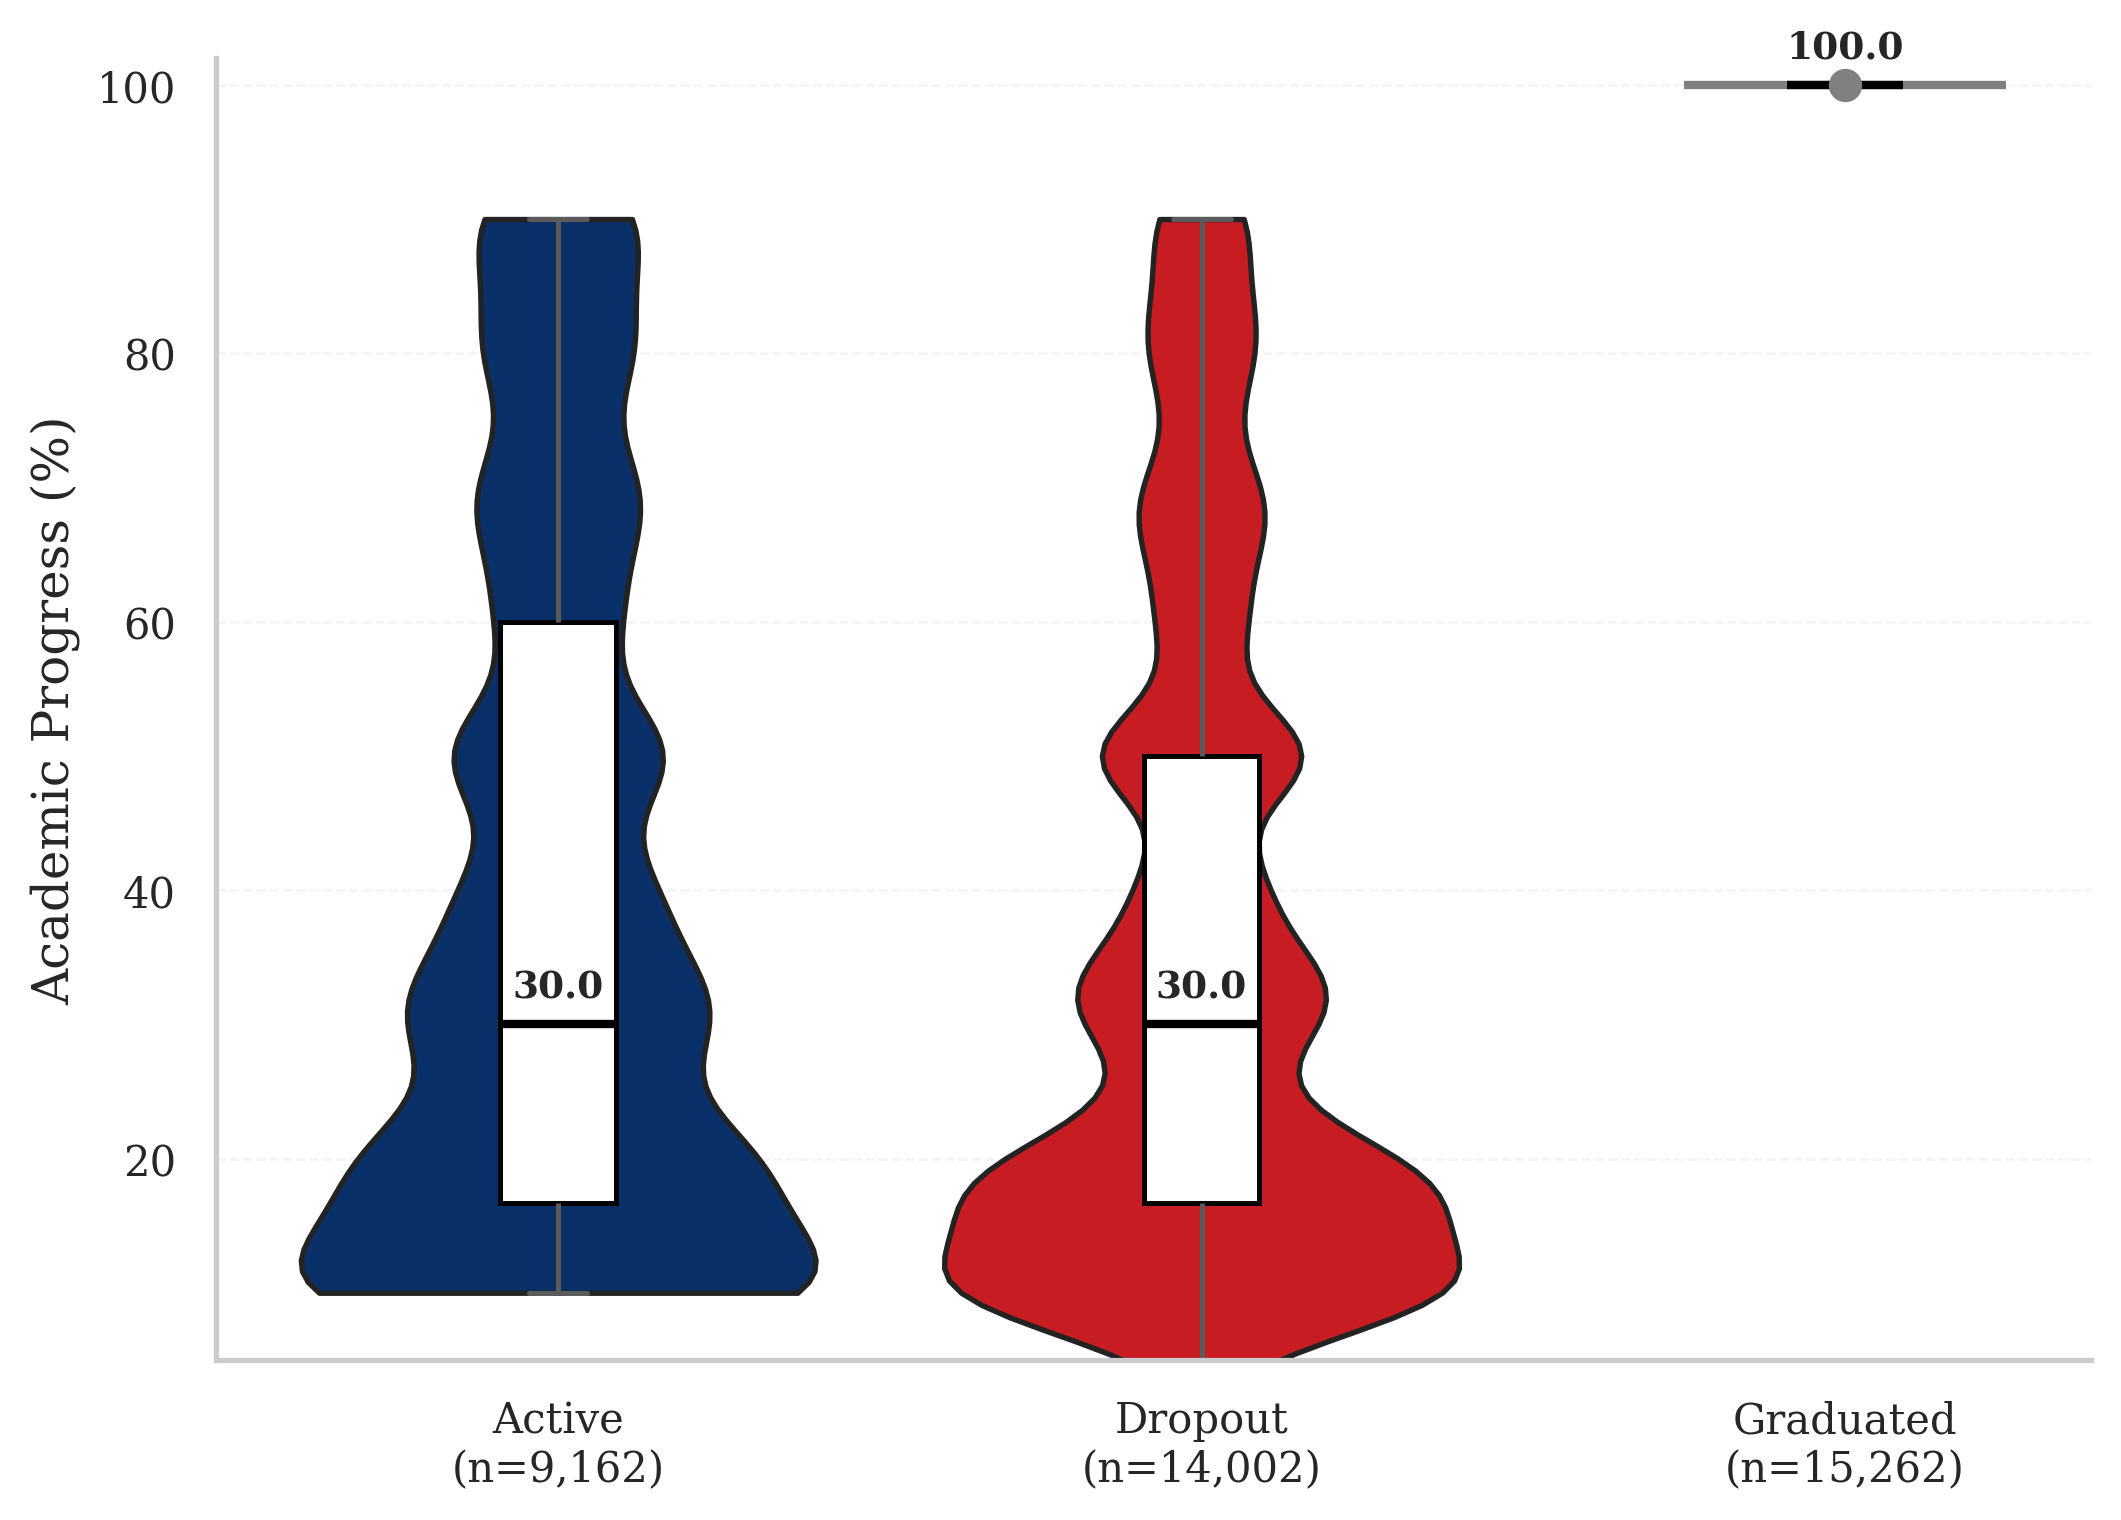

In [ ]:
# =============================================================================
# 4.2 DISTRIBUTION DIAGRAM
# Violin Plot + Boxplot
# =============================================================================

print_section("Distribution Diagram")

# =============================================================================
# Prepare Data
# =============================================================================

active_students = df[df["ACADEMIC_STATUS"] == "Active"]
dropout_students = df[df["ACADEMIC_STATUS"] == "Dropout"]
graduated_students = df[df["ACADEMIC_STATUS"] == "Graduated"]

# =============================================================================
# Create Figure
# =============================================================================

fig, ax = plt.subplots(figsize=(7.2, 5.2))

# =============================================================================
# Violin Plot
# =============================================================================

sns.violinplot(
    data=df[df["ACADEMIC_STATUS"] != "Graduated"],
    x="ACADEMIC_STATUS",
    y="AVANCE_NU",
    order=["Active", "Dropout"],
    palette=[BLUE_DARK, RED_DARK],
    inner=None,
    cut=0,
    linewidth=1.3,
    saturation=0.95,
    ax=ax
)

# =============================================================================
# Boxplot
# =============================================================================

sns.boxplot(
    data=df,
    x="ACADEMIC_STATUS",
    y="AVANCE_NU",
    order=["Active", "Dropout", "Graduated"],
    width=0.18,
    showfliers=False,
    boxprops={
        "facecolor": "white",
        "edgecolor": "black",
        "linewidth": 1.2
    },
    medianprops={
        "color": "black",
        "linewidth": 2
    },
    whiskerprops={
        "linewidth": 1.2
    },
    capprops={
        "linewidth": 1.2
    },
    ax=ax
)

# =============================================================================
# Graduated Reference
# =============================================================================

ax.plot(
    2,
    100,
    marker="o",
    markersize=7,
    color="gray",
    zorder=5
)

ax.hlines(
    100,
    1.75,
    2.25,
    colors="gray",
    linewidth=2
)

# =============================================================================
# Median Labels
# =============================================================================

for i, status in enumerate(["Active", "Dropout", "Graduated"]):

    median = df.loc[
        df["ACADEMIC_STATUS"] == status,
        "AVANCE_NU"
    ].median()

    ax.text(
        i,
        median + 2,
        f"{median:.1f}",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

# =============================================================================
# Sample Size
# =============================================================================

labels = [

    f"Active\n(n={len(active_students):,})",

    f"Dropout\n(n={len(dropout_students):,})",

    f"Graduated\n(n={len(graduated_students):,})"

]

ax.set_xticklabels(labels)

# =============================================================================
# Axis Labels
# =============================================================================

ax.set_xlabel("")

ax.set_ylabel("Academic Progress (%)")

ax.set_ylim(5, 102)

# =============================================================================
# Grid
# =============================================================================

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.20
)

sns.despine(
    top=True,
    right=True
)

# =============================================================================
# Layout
# =============================================================================

plt.tight_layout()

# =============================================================================
# Export Figures
# =============================================================================

plt.savefig(
    os.path.join(
        OUTPUT_FOLDER,
        "Figure_01_Distribution_Diagram.pdf"
    ),
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(
        OUTPUT_FOLDER,
        "Figure_01_Distribution_Diagram.png"
    ),
    dpi=600,
    bbox_inches="tight"
)

plt.show()


------------------------------------------------------------------------------------------
Pairplot Analysis
------------------------------------------------------------------------------------------


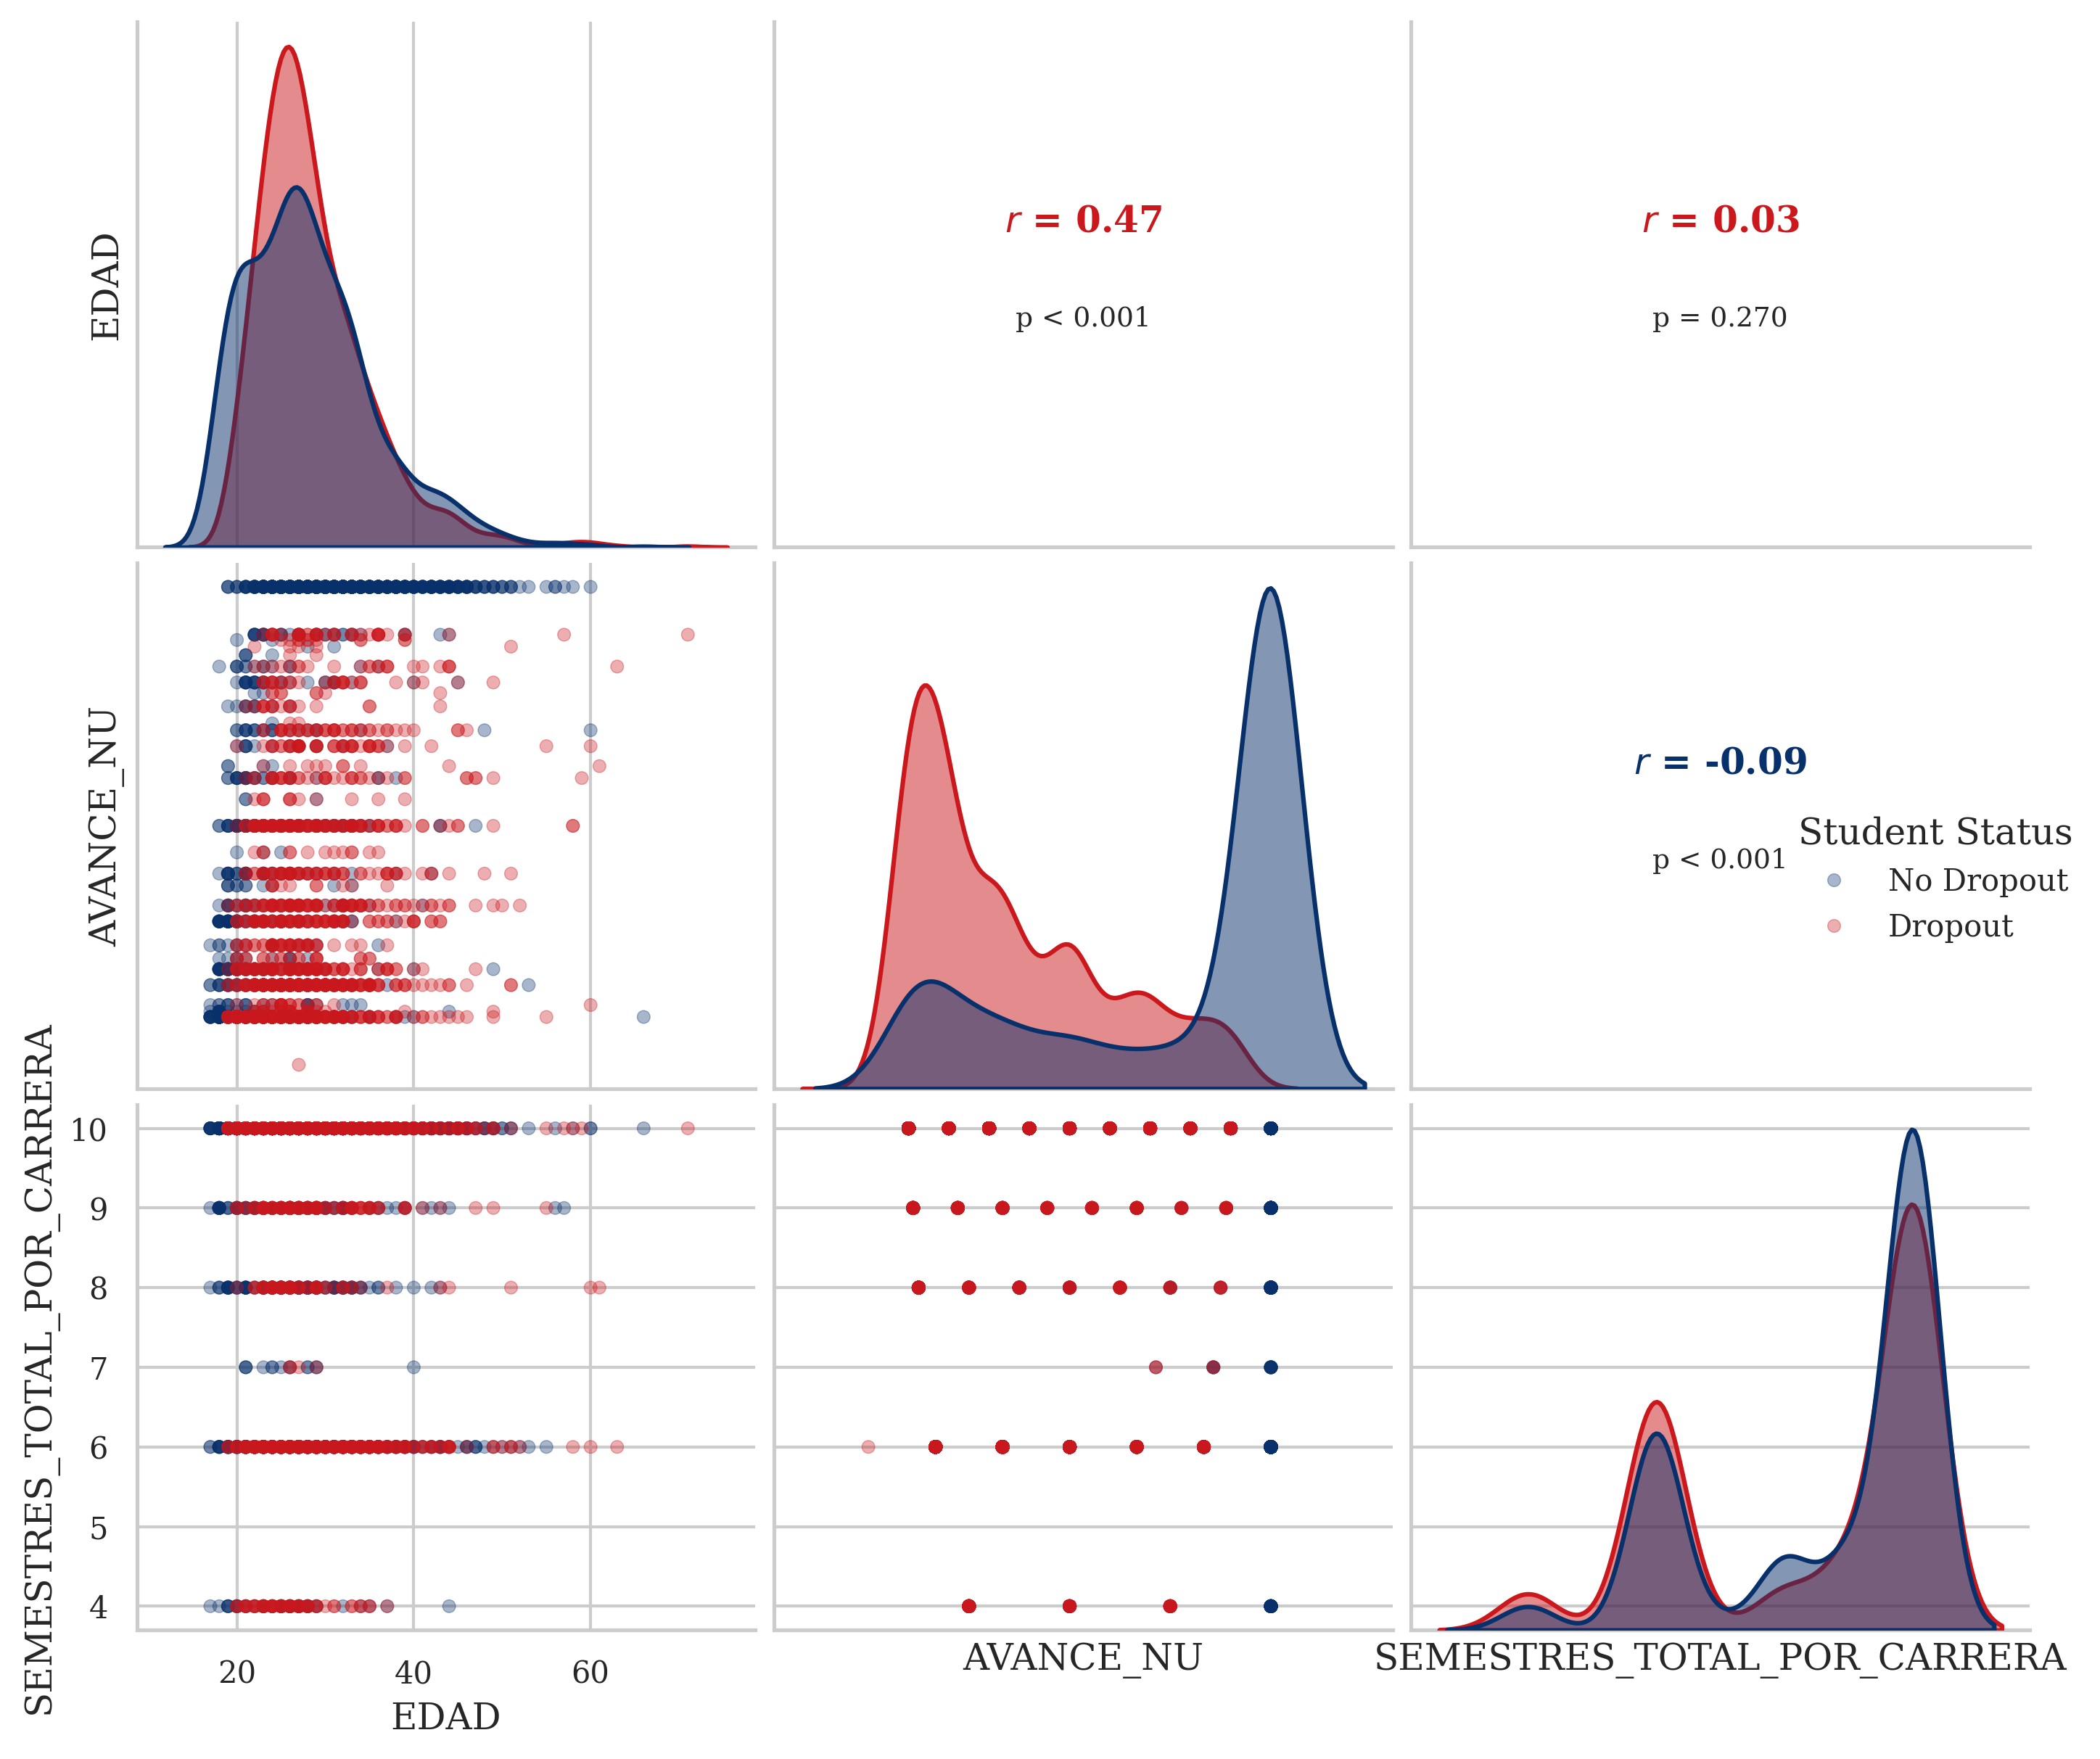

In [ ]:
# =============================================================================
# 4.3 PAIRPLOT ANALYSIS
# =============================================================================

print_section("Pairplot Analysis")

# =============================================================================
# Variables
# =============================================================================

variables = [
    "EDAD",
    "AVANCE_NU",
    "SEMESTRES_TOTAL_POR_CARRERA"
]

# =============================================================================
# Stratified Sampling
# =============================================================================

MAX_SAMPLES = 1500

df_plot = (
    df.groupby("target", group_keys=False)
      .apply(
          lambda x: x.sample(
              min(MAX_SAMPLES, len(x)),
              random_state=SEED
          )
      )
      .reset_index(drop=True)
)

# =============================================================================
# Color Palette
# =============================================================================

palette = {
    0: BLUE_DARK,
    1: RED_DARK
}

# =============================================================================
# Pearson Correlation Function
# =============================================================================

def correlation_annotation(x, y, **kwargs):

    ax = plt.gca()

    if len(ax.texts) == 0:

        r, p = pearsonr(x, y)

        color = RED_DARK if r >= 0 else BLUE_DARK

        ax.annotate(
            f"$r$ = {r:.2f}",
            xy=(0.50, 0.60),
            xycoords="axes fraction",
            ha="center",
            fontsize=12,
            color=color,
            fontweight="bold"
        )

        if p < 0.001:
            p_text = "p < 0.001"
        else:
            p_text = f"p = {p:.3f}"

        ax.annotate(
            p_text,
            xy=(0.50, 0.42),
            xycoords="axes fraction",
            ha="center",
            fontsize=9
        )

    ax.set_xticks([])
    ax.set_yticks([])

# =============================================================================
# PairGrid
# =============================================================================

g = sns.PairGrid(
    df_plot,
    vars=variables,
    hue="target",
    palette=palette,
    height=2.8,
    diag_sharey=False
)

# =============================================================================
# Lower Triangle
# =============================================================================

g.map_lower(
    sns.scatterplot,
    s=18,
    alpha=0.35,
    edgecolor=None
)

# =============================================================================
# Diagonal
# =============================================================================

g.map_diag(
    sns.kdeplot,
    fill=True,
    alpha=0.50,
    linewidth=1.5
)

# =============================================================================
# Upper Triangle
# =============================================================================

g.map_upper(
    correlation_annotation
)

# =============================================================================
# Legend
# =============================================================================

g.add_legend(title="Student Status")

legend = g._legend

legend.texts[0].set_text("No Dropout")
legend.texts[1].set_text("Dropout")

legend.get_frame().set_linewidth(0)

# =============================================================================
# Remove Spines
# =============================================================================

for ax in g.axes.flatten():

    sns.despine(
        ax=ax,
        top=True,
        right=True
    )

# =============================================================================
# Layout
# =============================================================================

g.fig.subplots_adjust(
    left=0.08,
    right=0.97,
    bottom=0.08,
    top=0.96,
    wspace=0.03,
    hspace=0.03
)

# =============================================================================
# Export Figures
# =============================================================================

g.savefig(
    os.path.join(
        OUTPUT_FOLDER,
        "Figure_02_Pairplot.pdf"
    ),
    bbox_inches="tight"
)

g.savefig(
    os.path.join(
        OUTPUT_FOLDER,
        "Figure_02_Pairplot.png"
    ),
    dpi=600,
    bbox_inches="tight"
)

plt.show()


------------------------------------------------------------------------------------------
Correlation Matrix
------------------------------------------------------------------------------------------


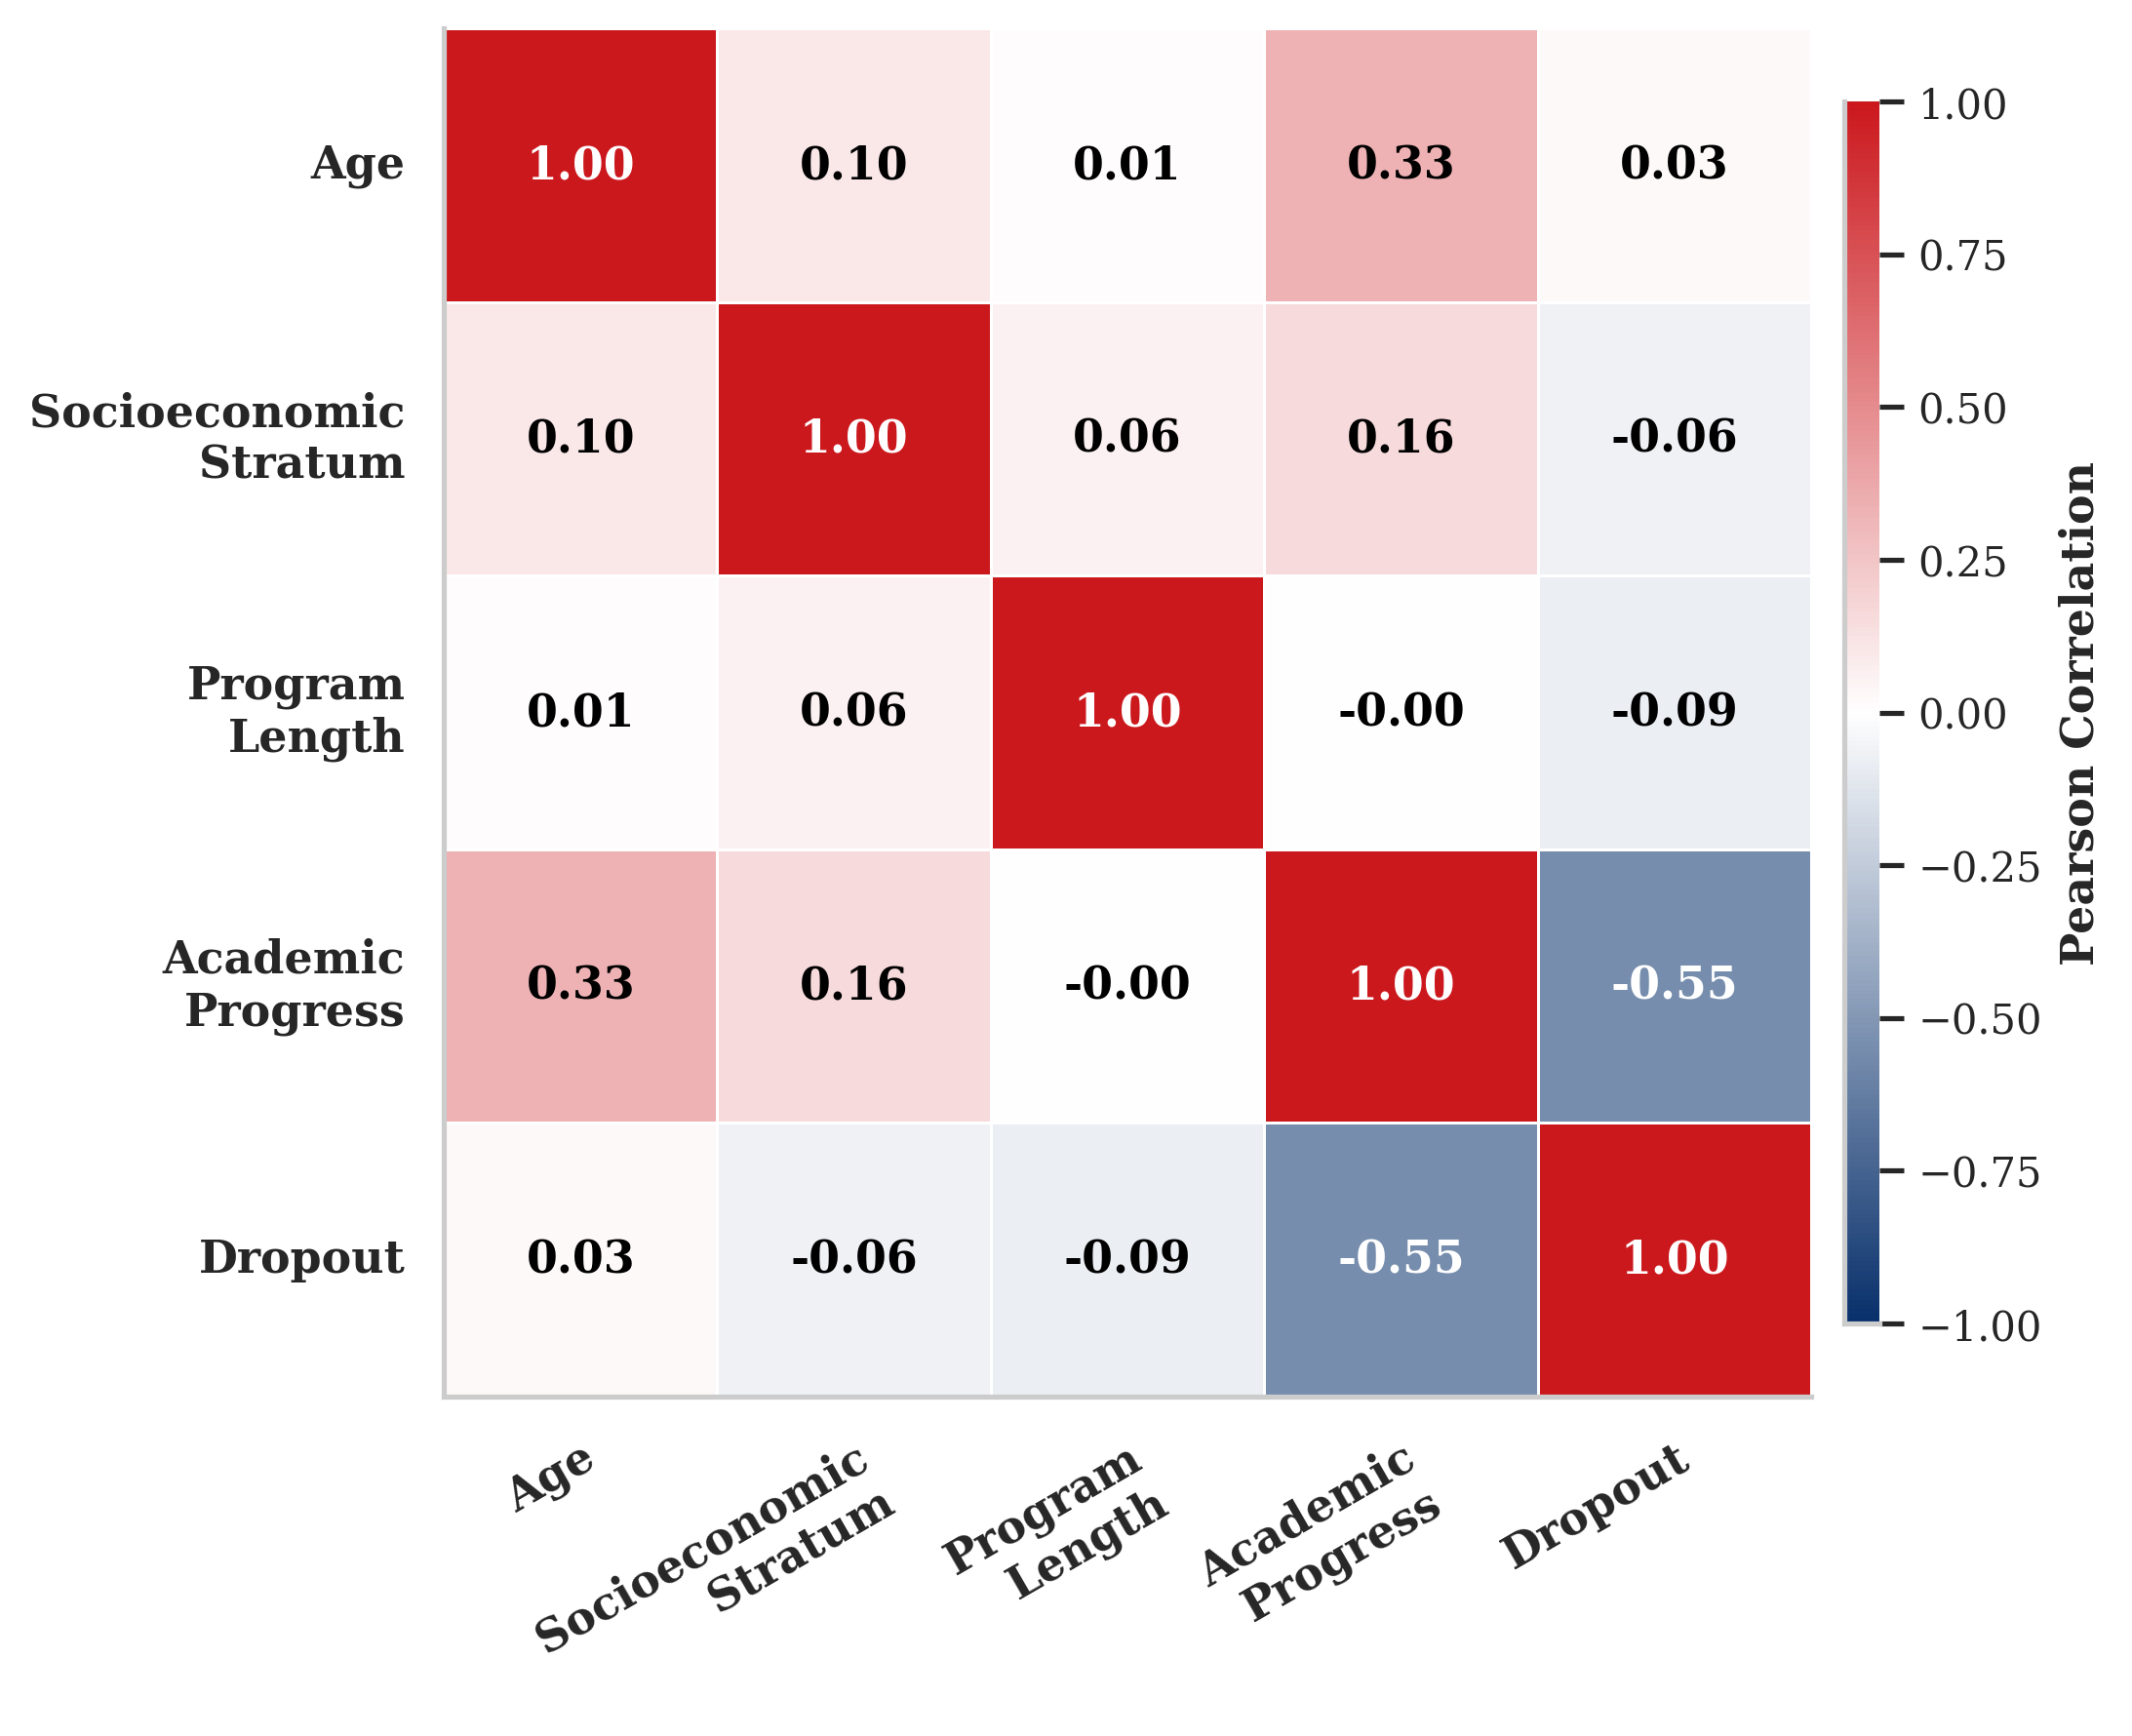

In [ ]:
# =============================================================================
# 4.4 CORRELATION MATRIX
# =============================================================================

print_section("Correlation Matrix")

# =============================================================================
# Variables
# =============================================================================

variables = [
    "EDAD",
    "ESTRATO",
    "SEMESTRES_TOTAL_POR_CARRERA",
    "AVANCE_NU",
    "target"
]

# =============================================================================
# Compute Pearson Correlation Matrix
# =============================================================================

corr = df[variables].corr(method="pearson")

# =============================================================================
# Rename Variables
# =============================================================================

labels = {
    "EDAD": "Age",
    "ESTRATO": "Socioeconomic\nStratum",
    "SEMESTRES_TOTAL_POR_CARRERA": "Program\nLength",
    "AVANCE_NU": "Academic\nProgress",
    "target": "Dropout"
}

corr.rename(
    index=labels,
    columns=labels,
    inplace=True
)

# =============================================================================
# Professional Colormap (Dark Blue → White → Dark Red)
# =============================================================================

cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "Journal",
    [
        BLUE_DARK,
        "#FFFFFF",
        RED_DARK
    ]
)

# =============================================================================
# Create Figure
# =============================================================================

fig, ax = plt.subplots(
    figsize=(7.4, 6.4)
)

heatmap = sns.heatmap(
    corr,
    cmap=cmap,
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.7,
    linecolor="white",
    annot=True,
    fmt=".2f",
    annot_kws={
        "fontsize": 11,
        "fontweight": "bold"
    },
    cbar_kws={
        "label": "Pearson Correlation",
        "shrink": 0.82,
        "aspect": 35,
        "pad": 0.02
    },
    ax=ax
)

# =============================================================================
# Automatic Annotation Color
# =============================================================================

for text in heatmap.texts:

    try:
        value = float(text.get_text())

        if abs(value) >= 0.50:
            text.set_color("white")
        else:
            text.set_color("black")

    except ValueError:
        pass

# =============================================================================
# Improve Axis Labels
# =============================================================================

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=30,
    ha="right",
    rotation_mode="anchor",
    fontsize=11,
    fontweight="bold"
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=11,
    fontweight="bold"
)

# =============================================================================
# Improve Colorbar
# =============================================================================

cbar = heatmap.collections[0].colorbar

cbar.ax.tick_params(
    labelsize=10
)

cbar.set_label(
    "Pearson Correlation",
    fontsize=11,
    fontweight="bold"
)

# =============================================================================
# Remove Spines
# =============================================================================

sns.despine(
    top=True,
    right=True,
    left=False,
    bottom=False
)

# =============================================================================
# Adjust Layout
# =============================================================================

plt.tight_layout()

# =============================================================================
# Export Figures
# =============================================================================

plt.savefig(
    os.path.join(
        OUTPUT_FOLDER,
        "Figure_03_Correlation_Matrix.pdf"
    ),
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(
        OUTPUT_FOLDER,
        "Figure_03_Correlation_Matrix.png"
    ),
    dpi=600,
    bbox_inches="tight"
)

plt.show()


------------------------------------------------------------------------------------------
Dropout Probability Across Academic Semesters
------------------------------------------------------------------------------------------


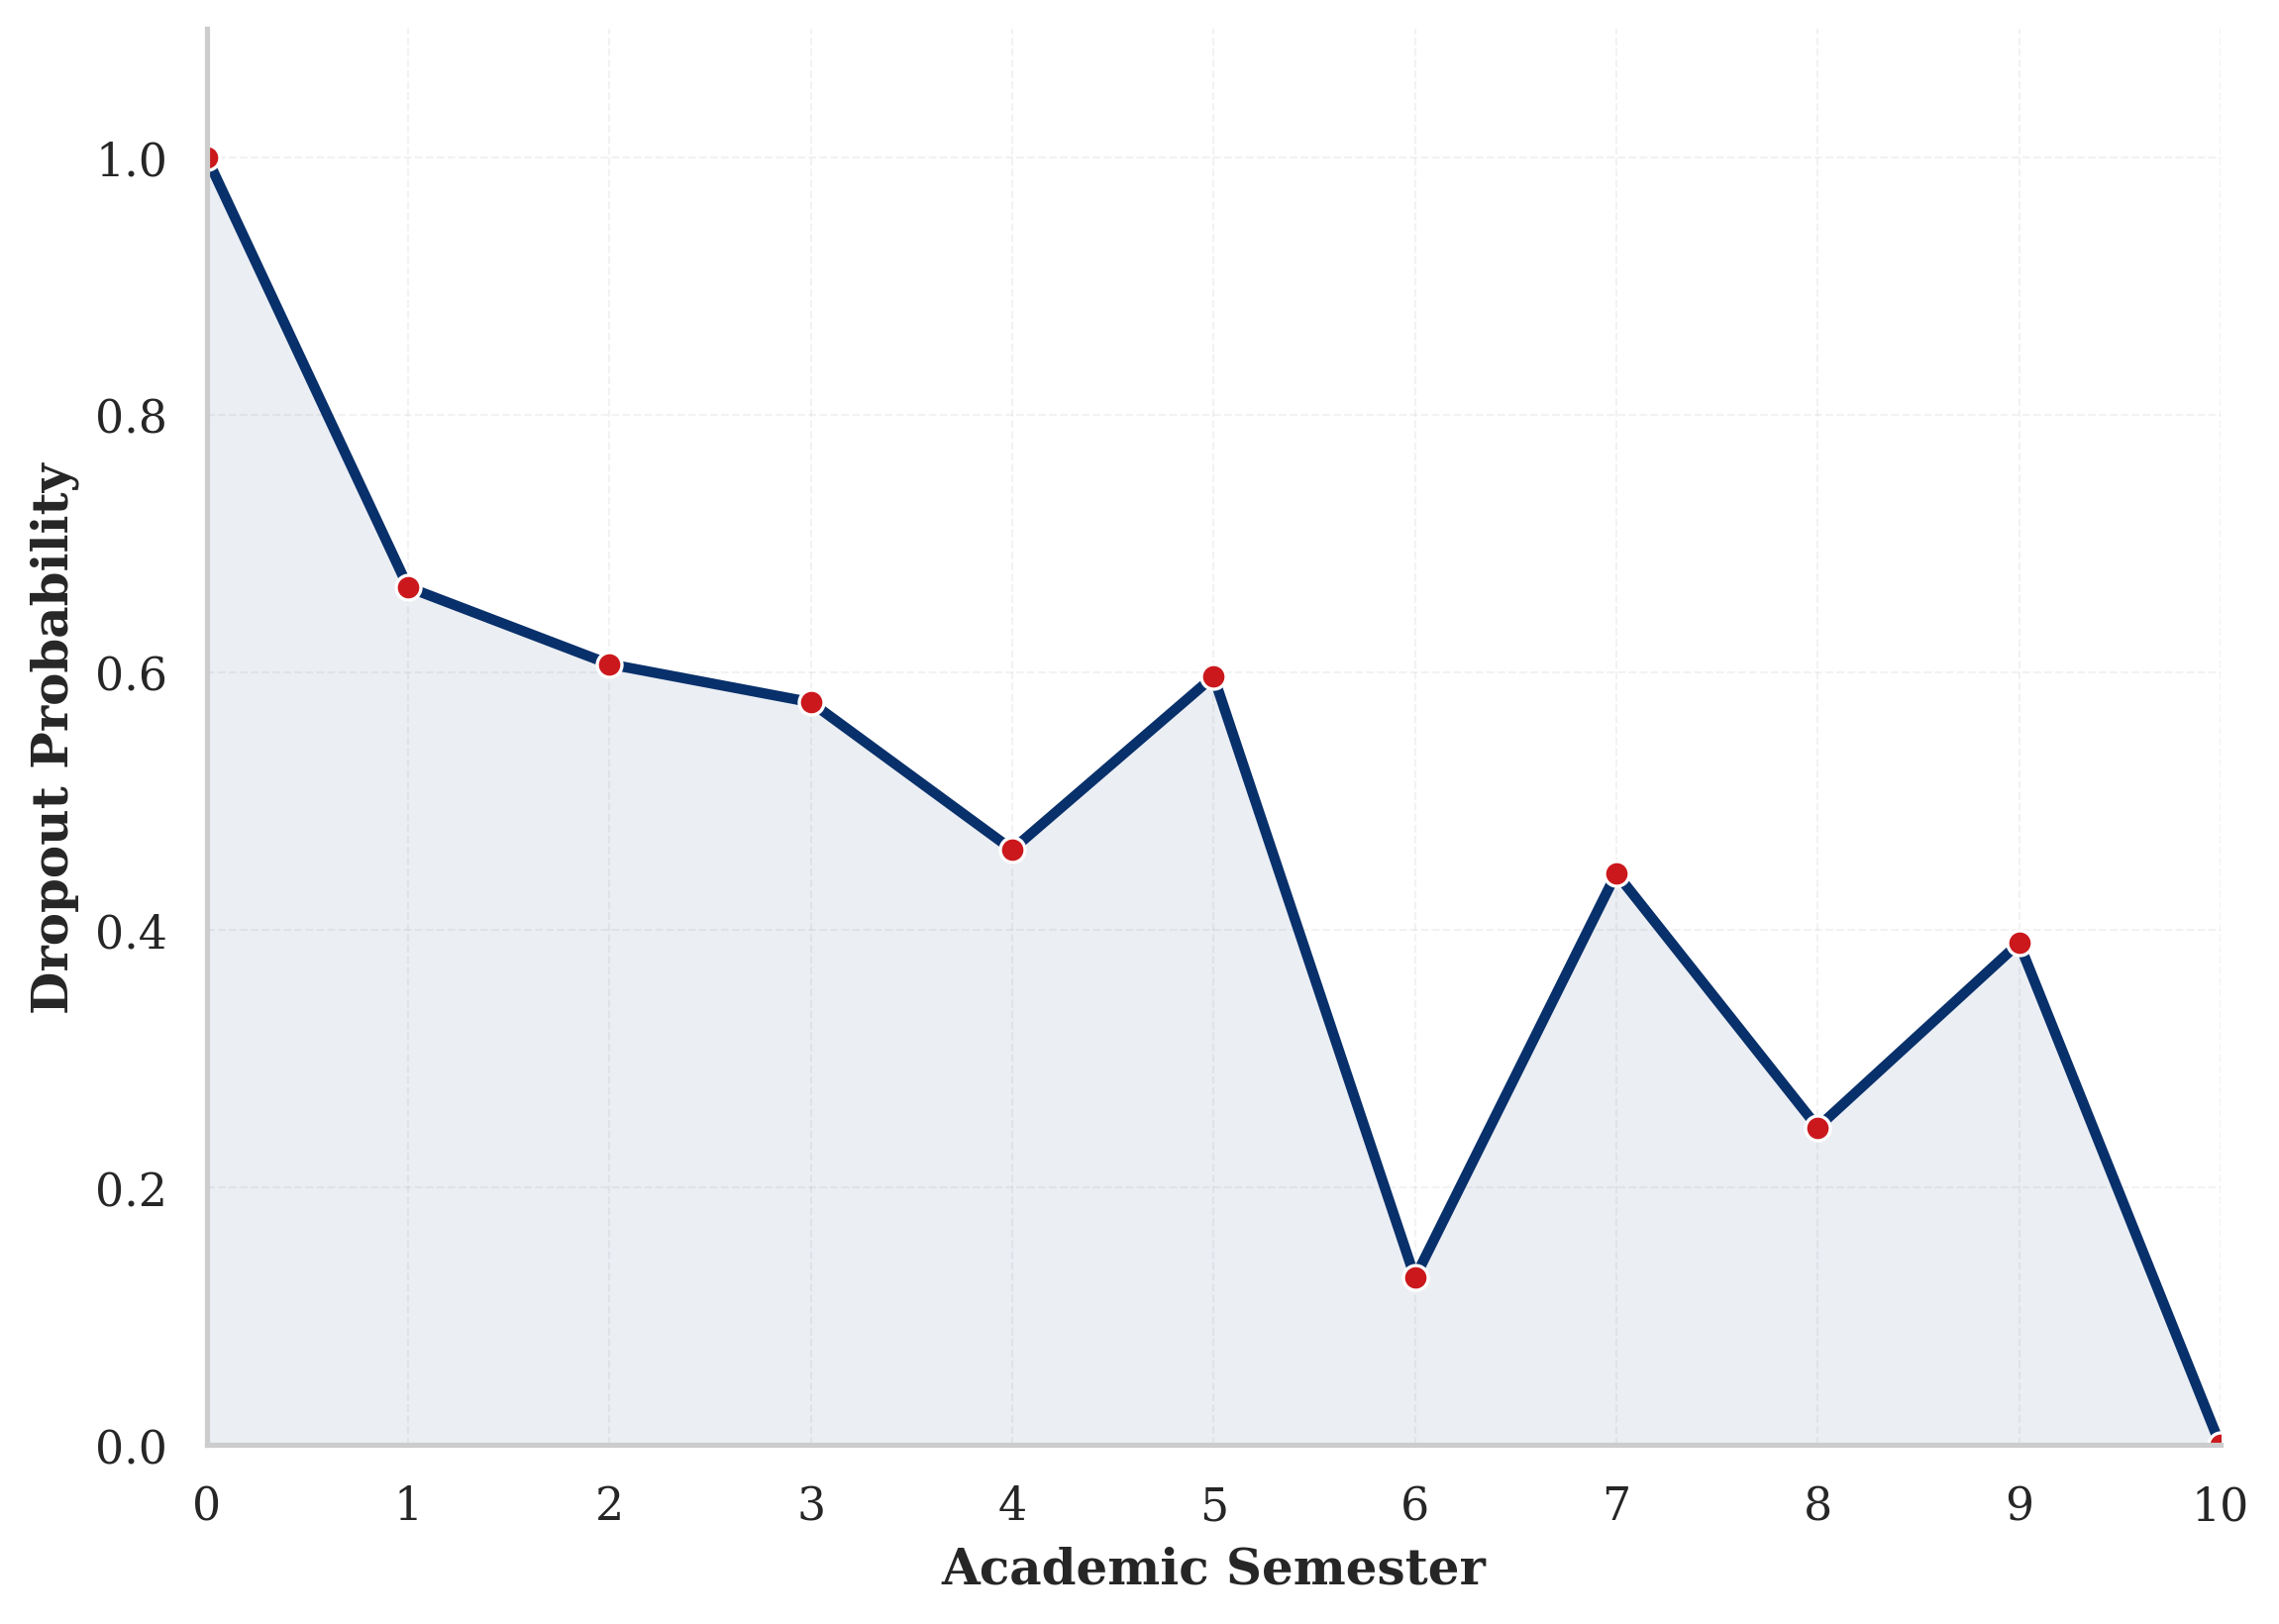

In [ ]:
# =============================================================================
# 4.5 DROPOUT PROBABILITY ACROSS ACADEMIC SEMESTERS
# =============================================================================

print_section("Dropout Probability Across Academic Semesters")

from matplotlib.ticker import MaxNLocator

# =============================================================================
# Calculate Dropout Probability by Semester
# =============================================================================

dropout = (
    df.groupby("NIVEL_ACTUAL")
      .agg(
          Dropout_Probability=("target", "mean"),
          Students=("target", "count")
      )
      .reset_index()
      .sort_values("NIVEL_ACTUAL")
)

# =============================================================================
# Create Figure
# =============================================================================

fig, ax = plt.subplots(figsize=(7.8, 5.6))

# =============================================================================
# Line
# =============================================================================

ax.plot(
    dropout["NIVEL_ACTUAL"],
    dropout["Dropout_Probability"],
    color=BLUE_DARK,
    linewidth=2.5,
    marker="o",
    markersize=6,
    markerfacecolor=RED_DARK,
    markeredgecolor="white",
    markeredgewidth=0.8
)

# =============================================================================
# Fill Area (optional, improves visualization)
# =============================================================================

ax.fill_between(
    dropout["NIVEL_ACTUAL"],
    dropout["Dropout_Probability"],
    color=BLUE_DARK,
    alpha=0.08
)

# =============================================================================
# Axis Labels
# =============================================================================

ax.set_xlabel(
    "Academic Semester",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Dropout Probability",
    fontsize=12,
    fontweight="bold"
)

# =============================================================================
# Axis Limits
# =============================================================================

ax.set_xlim(
    dropout["NIVEL_ACTUAL"].min(),
    dropout["NIVEL_ACTUAL"].max()
)

ax.set_ylim(
    0,
    dropout["Dropout_Probability"].max() * 1.10
)

ax.xaxis.set_major_locator(MaxNLocator(integer=True))

# =============================================================================
# Grid
# =============================================================================

ax.grid(
    True,
    linestyle="--",
    linewidth=0.5,
    alpha=0.25
)

# =============================================================================
# Remove Spines
# =============================================================================

sns.despine(
    top=True,
    right=True
)

# =============================================================================
# Tick Labels
# =============================================================================

ax.tick_params(
    axis="both",
    labelsize=11
)

# =============================================================================
# Layout
# =============================================================================

plt.tight_layout()

# =============================================================================
# Export Figures
# =============================================================================

plt.savefig(
    os.path.join(
        OUTPUT_FOLDER,
        "Figure_04_Dropout_Probability.pdf"
    ),
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(
        OUTPUT_FOLDER,
        "Figure_04_Dropout_Probability.png"
    ),
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# =============================================================================
# PHASE 5 - DATA PREPROCESSING, SMOTE BALANCING AND TRAIN-TEST SPLIT
# =============================================================================

print_title("PHASE 5 - DATA PREPROCESSING")

# =============================================================================
# 5.1 FEATURE SELECTION
# =============================================================================

print_section("Feature Selection")

FEATURES = [
    "EDAD",
    "ESTRATO",
    "NIVEL_ACTUAL",
    "SEMESTRES_TOTAL_POR_CARRERA",
    "AVANCE_NU"
]

X = df[FEATURES].copy()
y = df["target"].copy()

print("\nSelected Features:")
print(FEATURES)

print(f"\nTotal Records      : {len(X):,}")
print(f"Number of Features : {X.shape[1]}")


# =============================================================================
# 5.2 TRAIN-TEST SPLIT (BEFORE IMPUTATION TO PREVENT DATA LEAKAGE)
# =============================================================================

print_section("Train-Test Split")

X_train_raw, X_test_raw, y_train_raw, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=SEED
)

# =============================================================================
# 5.3 MISSING VALUE IMPUTATION (TRAIN-SET MEDIANS)
# =============================================================================

print_section("Missing Value Imputation")

# Compute medians ONLY on the training set to prevent data leakage
train_medians = X_train_raw.median()

# Apply the training medians to both training and test sets
X_train_raw = X_train_raw.fillna(train_medians)
X_test_raw = X_test_raw.fillna(train_medians)

print(f"{GREEN}✓ Missing values imputed using training set medians.{END}")

# =============================================================================
# 5.4 ORIGINAL CLASS DISTRIBUTION
# =============================================================================

print_section("Original Class Distribution")

# Print class distribution after the train-test split
print("\nTraining Set (Before SMOTE)")
print(y_train_raw.value_counts().sort_index())

print("\nTesting Set")
print(y_test.value_counts().sort_index())

# =============================================================================
# 5.5 SMOTE OVERSAMPLING
# =============================================================================

print_section("SMOTE Oversampling")

smote = SMOTE(
    sampling_strategy="auto",
    random_state=42,
    k_neighbors=5
)

X_train_res, y_train_res = smote.fit_resample(
    X_train_raw,
    y_train_raw
)

print("\nTraining Set (After SMOTE)")
print(y_train_res.value_counts().sort_index())

# =============================================================================
# 5.6 ROBUST FEATURE SCALING
# =============================================================================

print_section("Robust Feature Scaling")

scaler = RobustScaler()

X_train = scaler.fit_transform(X_train_res)

X_test = scaler.transform(X_test_raw)

# =============================================================================
# 5.7 PREPROCESSING SUMMARY
# =============================================================================

print(f"\n{BOLD}{'='*90}")
print("PREPROCESSING SUMMARY")
print(f"{'='*90}{END}")

print(f"Original Dataset                 : {X.shape}")
print(f"Training Dataset (Before SMOTE)  : {X_train_raw.shape}")
print(f"Testing Dataset                  : {X_test_raw.shape}")
print(f"Balanced Training Dataset        : {X_train.shape}")

print(f"\nTotal Students                  : {len(df):,}")
print(f"Training Students               : {len(X_train_raw):,}")
print(f"Testing Students                : {len(X_test_raw):,}")
print(f"Balanced Training Samples       : {len(X_train_res):,}")

print(
    f"\nSynthetic Samples Generated     : "
    f"{len(X_train_res)-len(X_train_raw):,}"
)

print(f"\n{GREEN}✓ Train-test split completed successfully.")
print("✓ SMOTE applied only to the training dataset.")
print("✓ Testing dataset remained completely unseen.")
print("✓ RobustScaler applied successfully.")
print(f"{END}")


PHASE 5 - DATA PREPROCESSING

------------------------------------------------------------------------------------------
Feature Selection
------------------------------------------------------------------------------------------

Selected Features:
['EDAD', 'ESTRATO', 'NIVEL_ACTUAL', 'SEMESTRES_TOTAL_POR_CARRERA', 'AVANCE_NU']

Total Records      : 38,426
Number of Features : 5

------------------------------------------------------------------------------------------
Train-Test Split
------------------------------------------------------------------------------------------

------------------------------------------------------------------------------------------
Missing Value Imputation
------------------------------------------------------------------------------------------
✓ Missing values imputed using training set medians.

------------------------------------------------------------------------------------------
Original Class Distribution
------------------------------------


------------------------------------------------------------------------------------------
Class Distribution
------------------------------------------------------------------------------------------


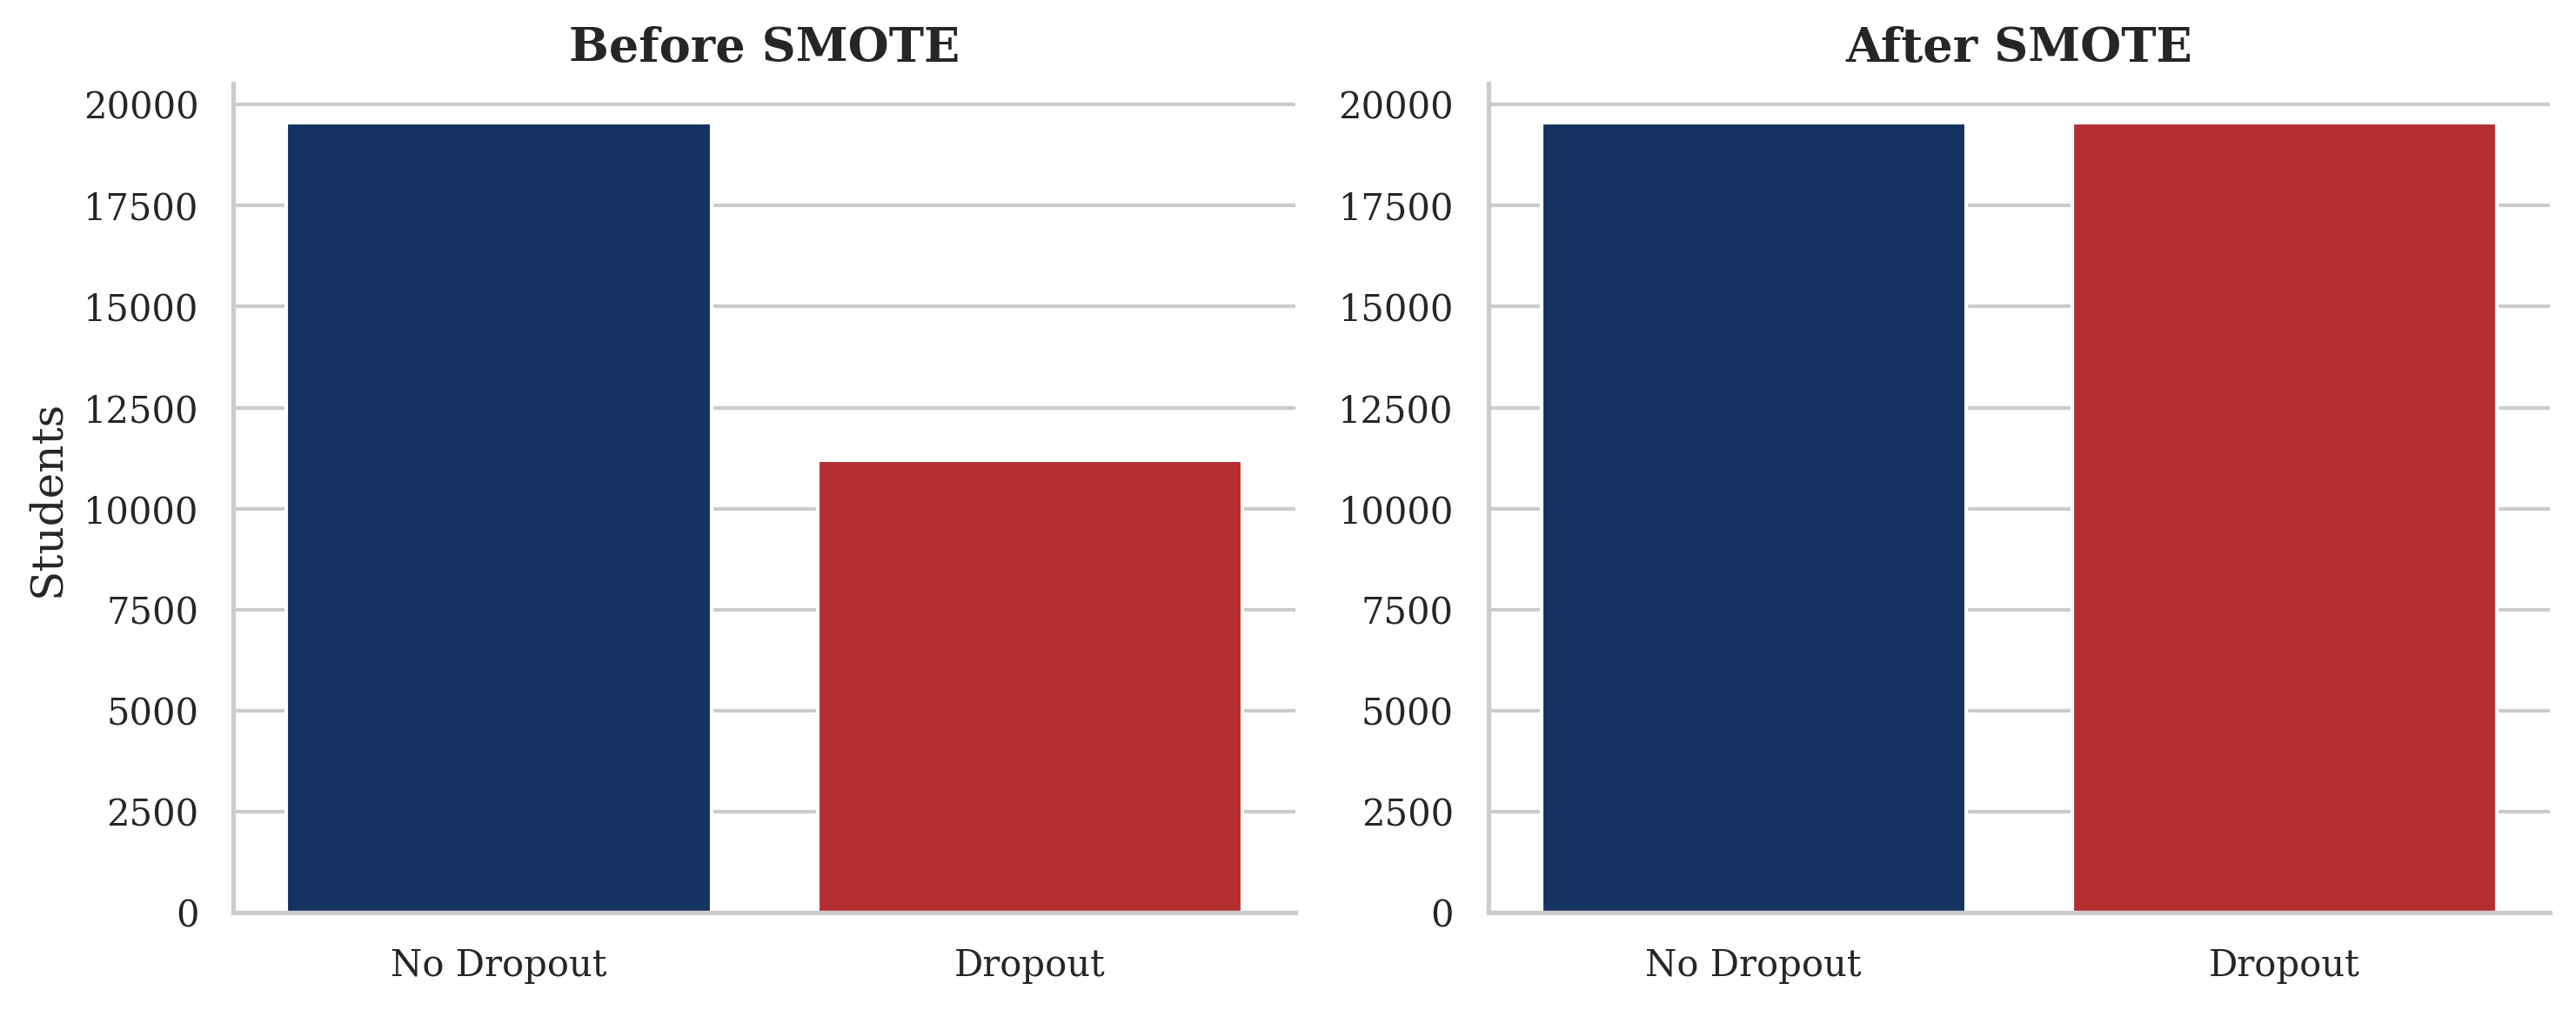

In [ ]:
# =============================================================================
# 5.8 CLASS DISTRIBUTION
# =============================================================================

print_section("Class Distribution")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Before SMOTE
sns.countplot(
    x=y_train_raw,
    palette=[BLUE_DARK, RED_DARK],
    ax=axes[0]
)

axes[0].set_title("Before SMOTE")
axes[0].set_xlabel("")
axes[0].set_ylabel("Students")
axes[0].set_xticklabels(["No Dropout", "Dropout"])

# After SMOTE
sns.countplot(
    x=y_train_res,
    palette=[BLUE_DARK, RED_DARK],
    ax=axes[1]
)

axes[1].set_title("After SMOTE")
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].set_xticklabels(["No Dropout", "Dropout"])

sns.despine()

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_FOLDER,
        "Figure_05_SMOTE_Balancing.pdf"
    ),
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(
        OUTPUT_FOLDER,
        "Figure_05_SMOTE_Balancing.png"
    ),
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# =============================================================================
# PHASE 6 - RESNET-ATTENTION MODEL DEVELOPMENT AND TRAINING
# =============================================================================

print_title("PHASE 7 - RESNET-ATTENTION MODEL")

# =============================================================================
# 6.1 RESNET-ATTENTION ARCHITECTURE
# =============================================================================

print_section("Building the ResNet-Attention Architecture")

def build_resnet_optimized(input_dim):
    """
    ResNet-Attention architecture for university dropout prediction.
    """

    inputs = Input(shape=(input_dim,))

    # -------------------------------------------------------------------------
    # Initial Projection Layer
    # -------------------------------------------------------------------------

    x_init = layers.Dense(
        128,
        kernel_regularizer=regularizers.l2(0.001)
    )(inputs)

    x_init = layers.BatchNormalization()(x_init)
    x_init = layers.Activation("swish")(x_init)

    # -------------------------------------------------------------------------
    # Residual Block
    # -------------------------------------------------------------------------

    x1 = layers.Dense(
        128,
        kernel_regularizer=regularizers.l2(0.001)
    )(x_init)

    x1 = layers.BatchNormalization()(x1)
    x1 = layers.Activation("swish")(x1)

    x2 = layers.Dense(
        128,
        kernel_regularizer=regularizers.l2(0.001)
    )(x1)

    x2 = layers.BatchNormalization()(x2)

    residual = layers.Add()([x_init, x2])

    residual = layers.Activation("swish")(residual)

    # -------------------------------------------------------------------------
    # Attention Mechanism
    # -------------------------------------------------------------------------

    attention = layers.Dense(
        128,
        activation="sigmoid"
    )(residual)

    x = layers.Multiply()([residual, attention])

    # -------------------------------------------------------------------------
    # Classification Head
    # -------------------------------------------------------------------------

    x = layers.Dense(
        64,
        activation="swish"
    )(x)

    x = layers.Dropout(0.50)(x)

    outputs = layers.Dense(
        1,
        activation="sigmoid"
    )(x)

    model = Model(
        inputs=inputs,
        outputs=outputs
    )

    # -------------------------------------------------------------------------
    # Model Compilation
    # -------------------------------------------------------------------------

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=0.0001
    )

    model.compile(

        optimizer=optimizer,

        loss="binary_crossentropy",

        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Recall(name="recall")
        ]
    )

    return model


# =============================================================================
# 6.2 MODEL INITIALIZATION
# =============================================================================

print_section("Initializing the Deep Learning Model")

tf.random.set_seed(SEED)

nn_model = build_resnet_optimized(
    X_train.shape[1]
)

print(f"{GREEN}✓ ResNet-Attention model created successfully.{END}")


# =============================================================================
# 6.3 CALLBACK CONFIGURATION
# =============================================================================

print_section("Configuring Training Callbacks")

early_stopping = EarlyStopping(

    monitor="val_loss",

    patience=15,

    restore_best_weights=True

)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.50,

    patience=5,

    min_lr=1e-5,

    verbose=1

)

print(f"{GREEN}✓ EarlyStopping configured.{END}")
print(f"{GREEN}✓ ReduceLROnPlateau configured.{END}")


# =============================================================================
# 6.4 MODEL TRAINING
# =============================================================================

print_section("Training the ResNet-Attention Model")

history = nn_model.fit(

    X_train,

    y_train_res,

    validation_data=(X_test, y_test),

    epochs=50,

    batch_size=32,

    callbacks=[
        early_stopping,
        reduce_lr
    ],

    verbose=1

)

print(f"\n{GREEN}✓ Model training completed successfully.{END}")


PHASE 7 - RESNET-ATTENTION MODEL

------------------------------------------------------------------------------------------
Building the ResNet-Attention Architecture
------------------------------------------------------------------------------------------

------------------------------------------------------------------------------------------
Initializing the Deep Learning Model
------------------------------------------------------------------------------------------
✓ ResNet-Attention model created successfully.

------------------------------------------------------------------------------------------
Configuring Training Callbacks
------------------------------------------------------------------------------------------
✓ EarlyStopping configured.
✓ ReduceLROnPlateau configured.

------------------------------------------------------------------------------------------
Training the ResNet-Attention Model
-----------------------------------------------------------------------

In [ ]:
# =============================================================================
# PHASE 7 - DECISION THRESHOLD OPTIMIZATION
# =============================================================================

print_title("PHASE 7 - DECISION THRESHOLD OPTIMIZATION")

# =============================================================================
# 7.1 PREDICT CLASS PROBABILITIES
# =============================================================================

print_section("Predicting Class Probabilities")

# Generate probability scores using the trained ResNet-Attention model

y_scores = nn_model.predict(
    X_test,
    verbose=0
).ravel()

print(f"{GREEN}✓ Probability prediction completed successfully.{END}")

# =============================================================================
# 7.2 PRECISION-RECALL ANALYSIS
# =============================================================================

print_section("Precision-Recall Analysis")

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_scores
)

# =============================================================================
# 7.3 OPTIMAL THRESHOLD SEARCH
# =============================================================================

print_section("Searching for the Optimal Classification Threshold")

# Align arrays by discarding the last synthetic point from precision and recall
precision_adj = precision[:-1]
recall_adj = recall[:-1]

# Compute denominator avoiding division by zero
denominator = np.where(
    (precision_adj + recall_adj) == 0,
    1.0,
    precision_adj + recall_adj
)

f1_scores = (
    2 * precision_adj * recall_adj
) / denominator

best_index = np.argmax(f1_scores)

optimal_threshold = thresholds[best_index]

optimal_f1 = f1_scores[best_index]

print(f"\nOptimal Threshold : {optimal_threshold:.4f}")
print(f"Maximum F1-Score  : {optimal_f1:.4f}")

# =============================================================================
# 7.4 FINAL CLASSIFICATION
# =============================================================================

print_section("Generating Final Predictions")

# Convert probabilities into binary predictions

y_pred_final = (
    y_scores >= optimal_threshold
).astype(int)

print(f"{GREEN}✓ Final predictions generated successfully.{END}")


PHASE 7 - DECISION THRESHOLD OPTIMIZATION

------------------------------------------------------------------------------------------
Predicting Class Probabilities
------------------------------------------------------------------------------------------
✓ Probability prediction completed successfully.

------------------------------------------------------------------------------------------
Precision-Recall Analysis
------------------------------------------------------------------------------------------

------------------------------------------------------------------------------------------
Searching for the Optimal Classification Threshold
------------------------------------------------------------------------------------------

Optimal Threshold : 0.4854
Maximum F1-Score  : 0.8481

------------------------------------------------------------------------------------------
Generating Final Predictions
---------------------------------------------------------------------------

Optimal Threshold : 0.4854
Precision         : 0.7634
Recall            : 0.9539
Maximum F1-score  : 0.8481


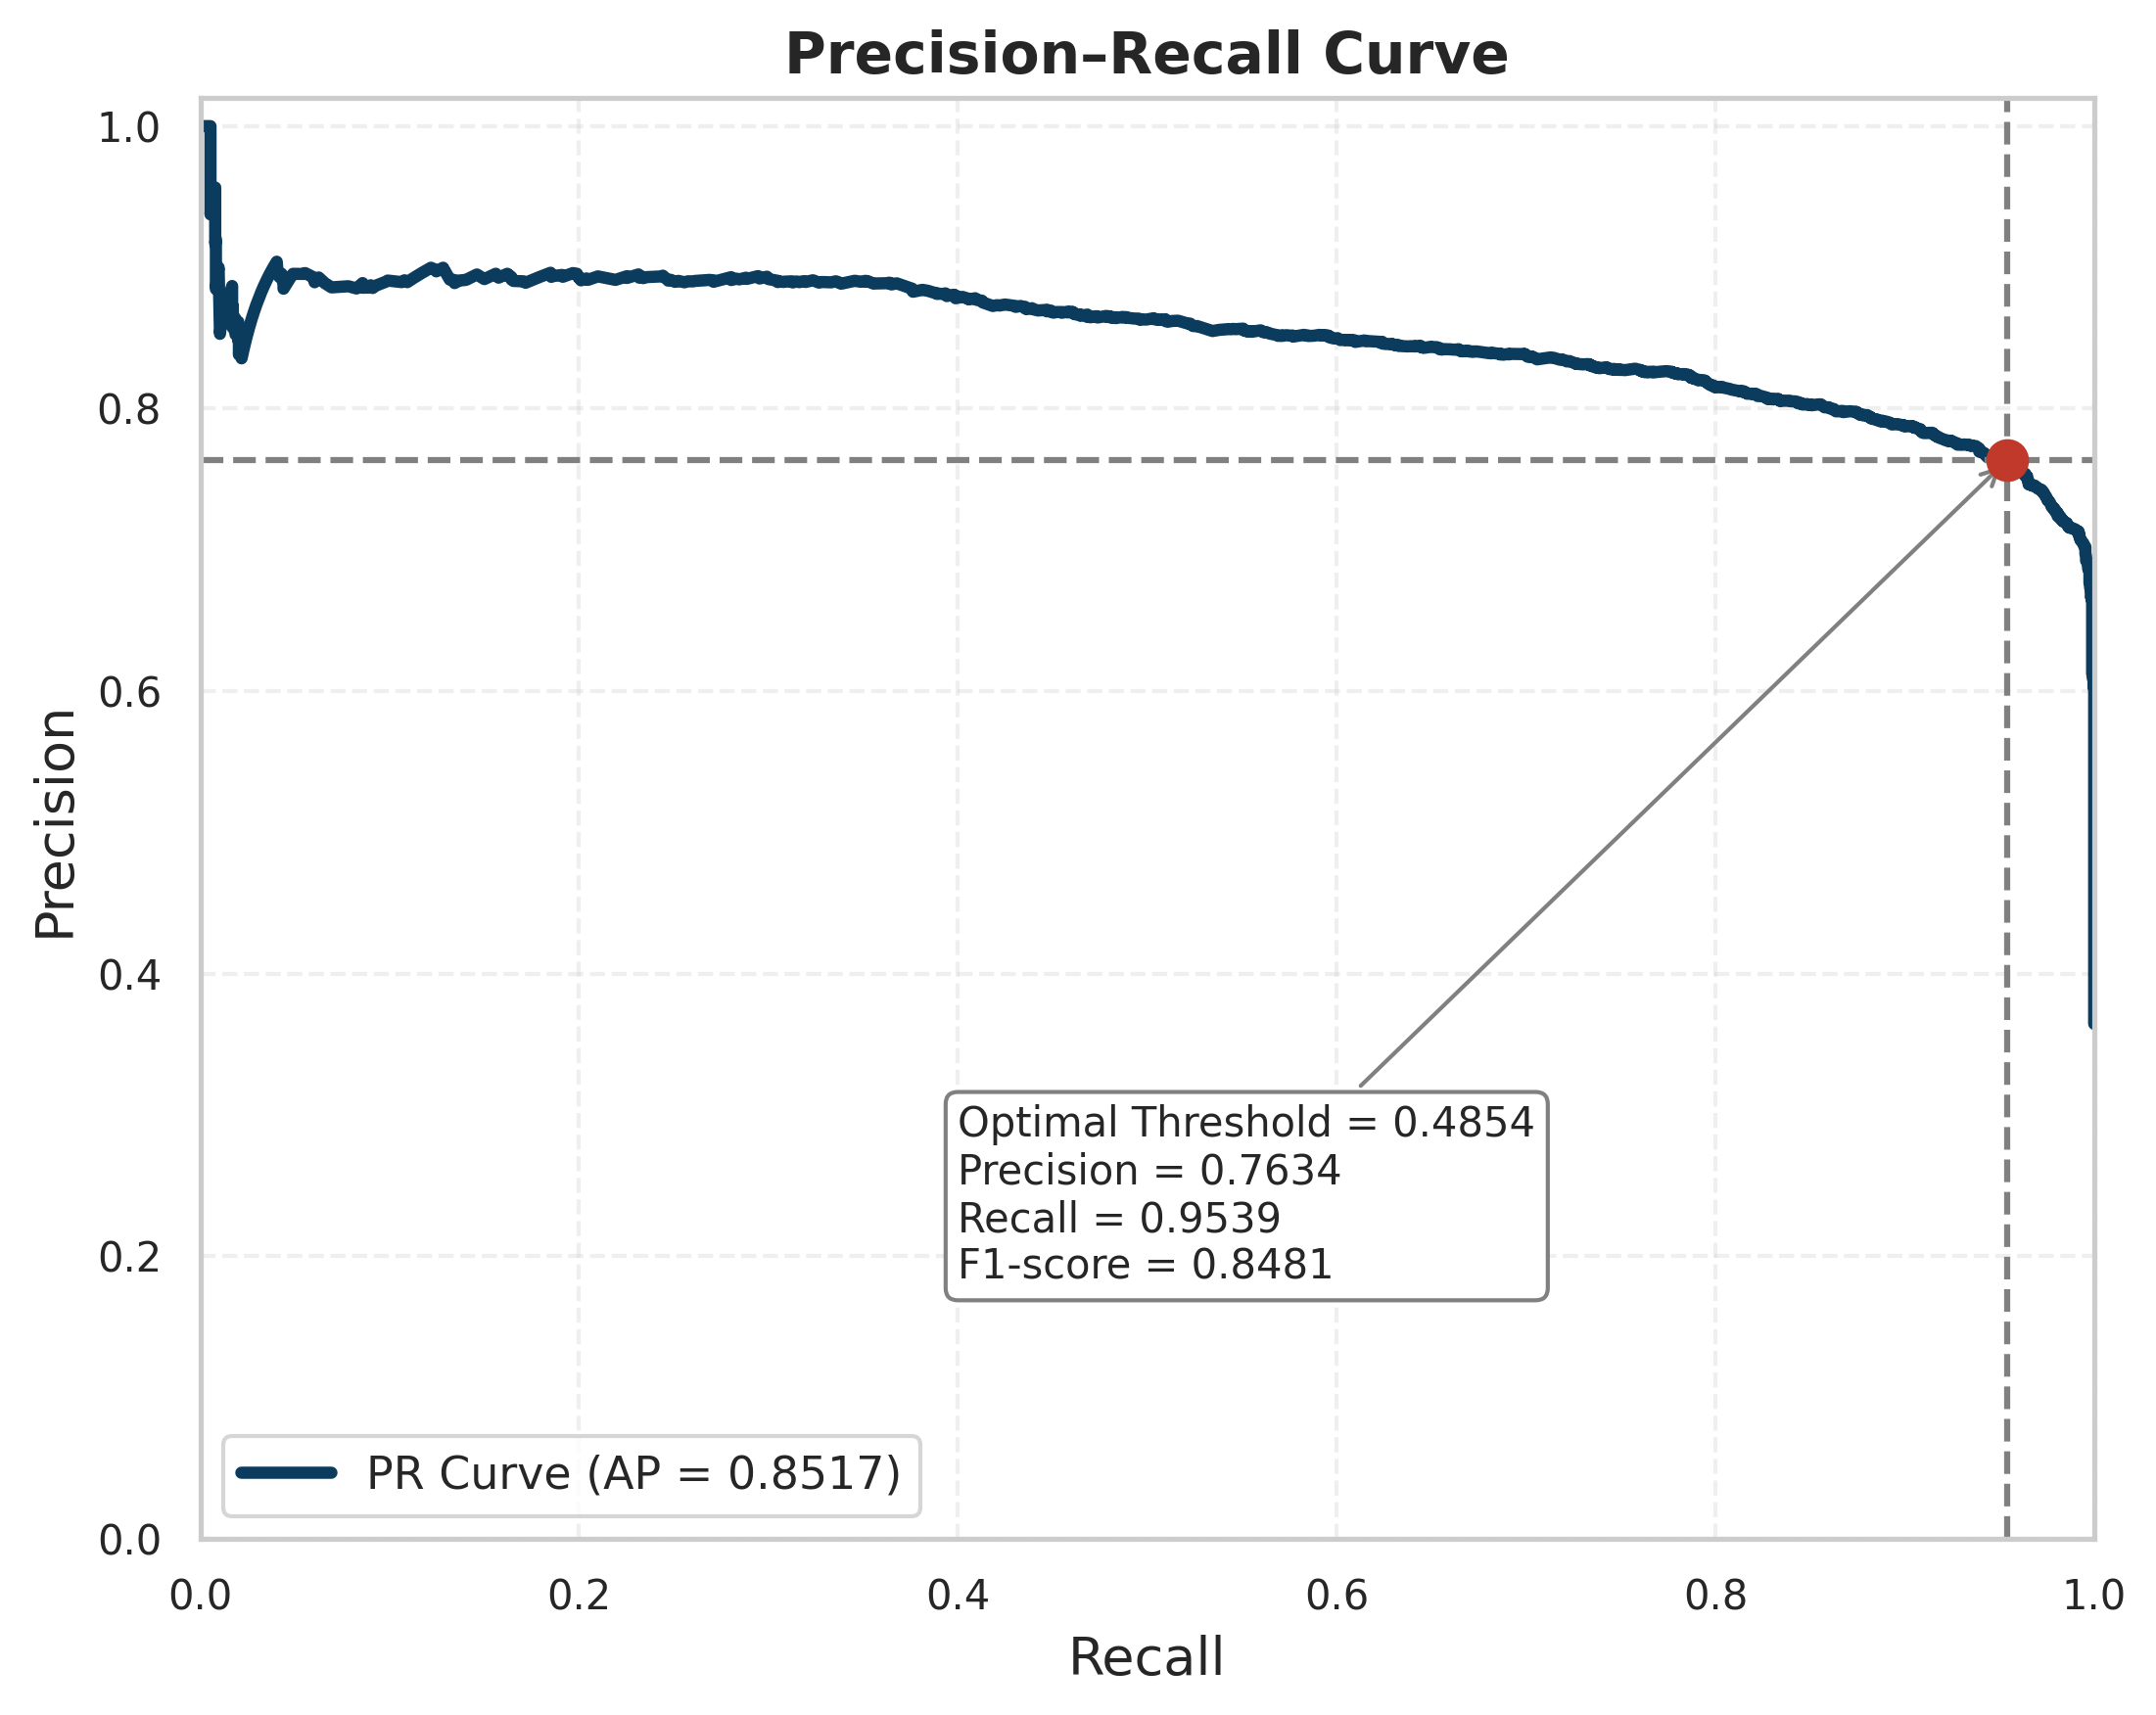

In [ ]:
# ============================================================
# Precision-Recall Curve
# ============================================================

from sklearn.metrics import average_precision_score

# ============================================================
# INPUTS
# ============================================================

# True labels
y_true = y_test

# Predicted probabilities
y_scores = y_scores

# ============================================================
# COMPUTE CURVE
# ============================================================

precision, recall, thresholds = precision_recall_curve(
    y_true,
    y_scores
)

average_precision = average_precision_score(
    y_true,
    y_scores
)

# ============================================================
# COMPUTE F1
# ============================================================

f1 = (
    2 * precision[:-1] * recall[:-1]
) / (
    precision[:-1] + recall[:-1] + 1e-12
)

best_idx = np.argmax(f1)

best_threshold = thresholds[best_idx]
best_precision = precision[best_idx]
best_recall = recall[best_idx]
best_f1 = f1[best_idx]

print("="*60)
print(f"Optimal Threshold : {best_threshold:.4f}")
print(f"Precision         : {best_precision:.4f}")
print(f"Recall            : {best_recall:.4f}")
print(f"Maximum F1-score  : {best_f1:.4f}")
print("="*60)

# ============================================================
# STYLE
# ============================================================

plt.rcParams.update({

    "font.family":"Arial",

    "font.size":12,

    "axes.titlesize":14,

    "axes.labelsize":13,

    "legend.fontsize":11

})

# ============================================================
# FIGURE
# ============================================================

fig, ax = plt.subplots(figsize=(7.5,6))

# Precision-Recall Curve

ax.plot(

    recall,

    precision,

    color="#0B3C5D",

    linewidth=3,

    label=f"PR Curve (AP = {average_precision:.4f})"

)

# Optimal Point

ax.scatter(

    best_recall,

    best_precision,

    color="#C0392B",

    s=90,

    zorder=10

)

# Dashed lines

ax.axvline(

    best_recall,

    linestyle="--",

    linewidth=1.5,

    color="gray"

)

ax.axhline(

    best_precision,

    linestyle="--",

    linewidth=1.5,

    color="gray"

)

# Annotation

text = (

    f"Optimal Threshold = {best_threshold:.4f}\n"

    f"Precision = {best_precision:.4f}\n"

    f"Recall = {best_recall:.4f}\n"

    f"F1-score = {best_f1:.4f}"

)

ax.annotate(

    text,

    xy=(best_recall,best_precision),

    xytext=(0.40,0.18),

    textcoords="axes fraction",

    fontsize=10,

    bbox=dict(

        boxstyle="round",

        fc="white",

        ec="gray"

    ),

    arrowprops=dict(

        arrowstyle="->",

        color="gray"

    )

)

# ============================================================
# AXES
# ============================================================

ax.set_xlim(0,1)

ax.set_ylim(0,1.02)

ax.set_xlabel("Recall")

ax.set_ylabel("Precision")

ax.set_title("Precision–Recall Curve")

ax.grid(

    linestyle="--",

    alpha=0.30

)

ax.legend(

    loc="lower left",

    frameon=True

)

plt.tight_layout()

# ============================================================
# EXPORT
# ============================================================

plt.savefig(

    "Precision_Recall_Curve.pdf",

    dpi=600,

    bbox_inches="tight"

)

plt.savefig(

    "Precision_Recall_Curve.png",

    dpi=600,

    bbox_inches="tight"

)

plt.savefig(

    "Precision_Recall_Curve.tiff",

    dpi=600,

    bbox_inches="tight"

)

plt.show()

In [ ]:
# =============================================================================
# PHASE 8 - MODEL PERFORMANCE EVALUATION
# =============================================================================

print_title("PHASE 8 - MODEL PERFORMANCE EVALUATION")

# =============================================================================
# 8.1 CLASSIFICATION REPORT
# =============================================================================

print_section("Classification Report")

report = classification_report(
    y_test,
    y_pred_final,
    target_names=[
        "Persistence",
        "Dropout"
    ]
)

print(report)

# =============================================================================
# 8.2 PERFORMANCE METRICS
# =============================================================================

print_section("Performance Metrics")

accuracy = accuracy_score(
    y_test,
    y_pred_final
)

precision = precision_score(
    y_test,
    y_pred_final
)

recall = recall_score(
    y_test,
    y_pred_final
)

f1 = f1_score(
    y_test,
    y_pred_final
)

auc_score = roc_auc_score(
    y_test,
    y_scores
)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {auc_score:.4f}")

# =============================================================================
# 8.3 CONFUSION MATRIX
# =============================================================================

print_section("Confusion Matrix")

cm = confusion_matrix(
    y_test,
    y_pred_final
)

print(cm)

# =============================================================================
# 8.4 EVALUATION SUMMARY
# =============================================================================

print_section("Evaluation Summary")

print(f"{GREEN}✓ Classification report generated successfully.")
print("✓ Performance metrics computed successfully.")
print("✓ Confusion matrix generated successfully.")
print("✓ ROC-AUC score computed successfully.")
print(f"{END}")


PHASE 8 - MODEL PERFORMANCE EVALUATION

------------------------------------------------------------------------------------------
Classification Report
------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

 Persistence       0.97      0.83      0.89      4885
     Dropout       0.76      0.95      0.85      2801

    accuracy                           0.88      7686
   macro avg       0.87      0.89      0.87      7686
weighted avg       0.89      0.88      0.88      7686


------------------------------------------------------------------------------------------
Performance Metrics
------------------------------------------------------------------------------------------
Accuracy  : 0.8755
Precision : 0.7634
Recall    : 0.9539
F1-Score  : 0.8481
ROC-AUC   : 0.9392

------------------------------------------------------------------------------------------
Confusion Matrix
---------------------


PHASE 9 - LEARNING CURVES

------------------------------------------------------------------------------------------
Training and Validation Performance
------------------------------------------------------------------------------------------


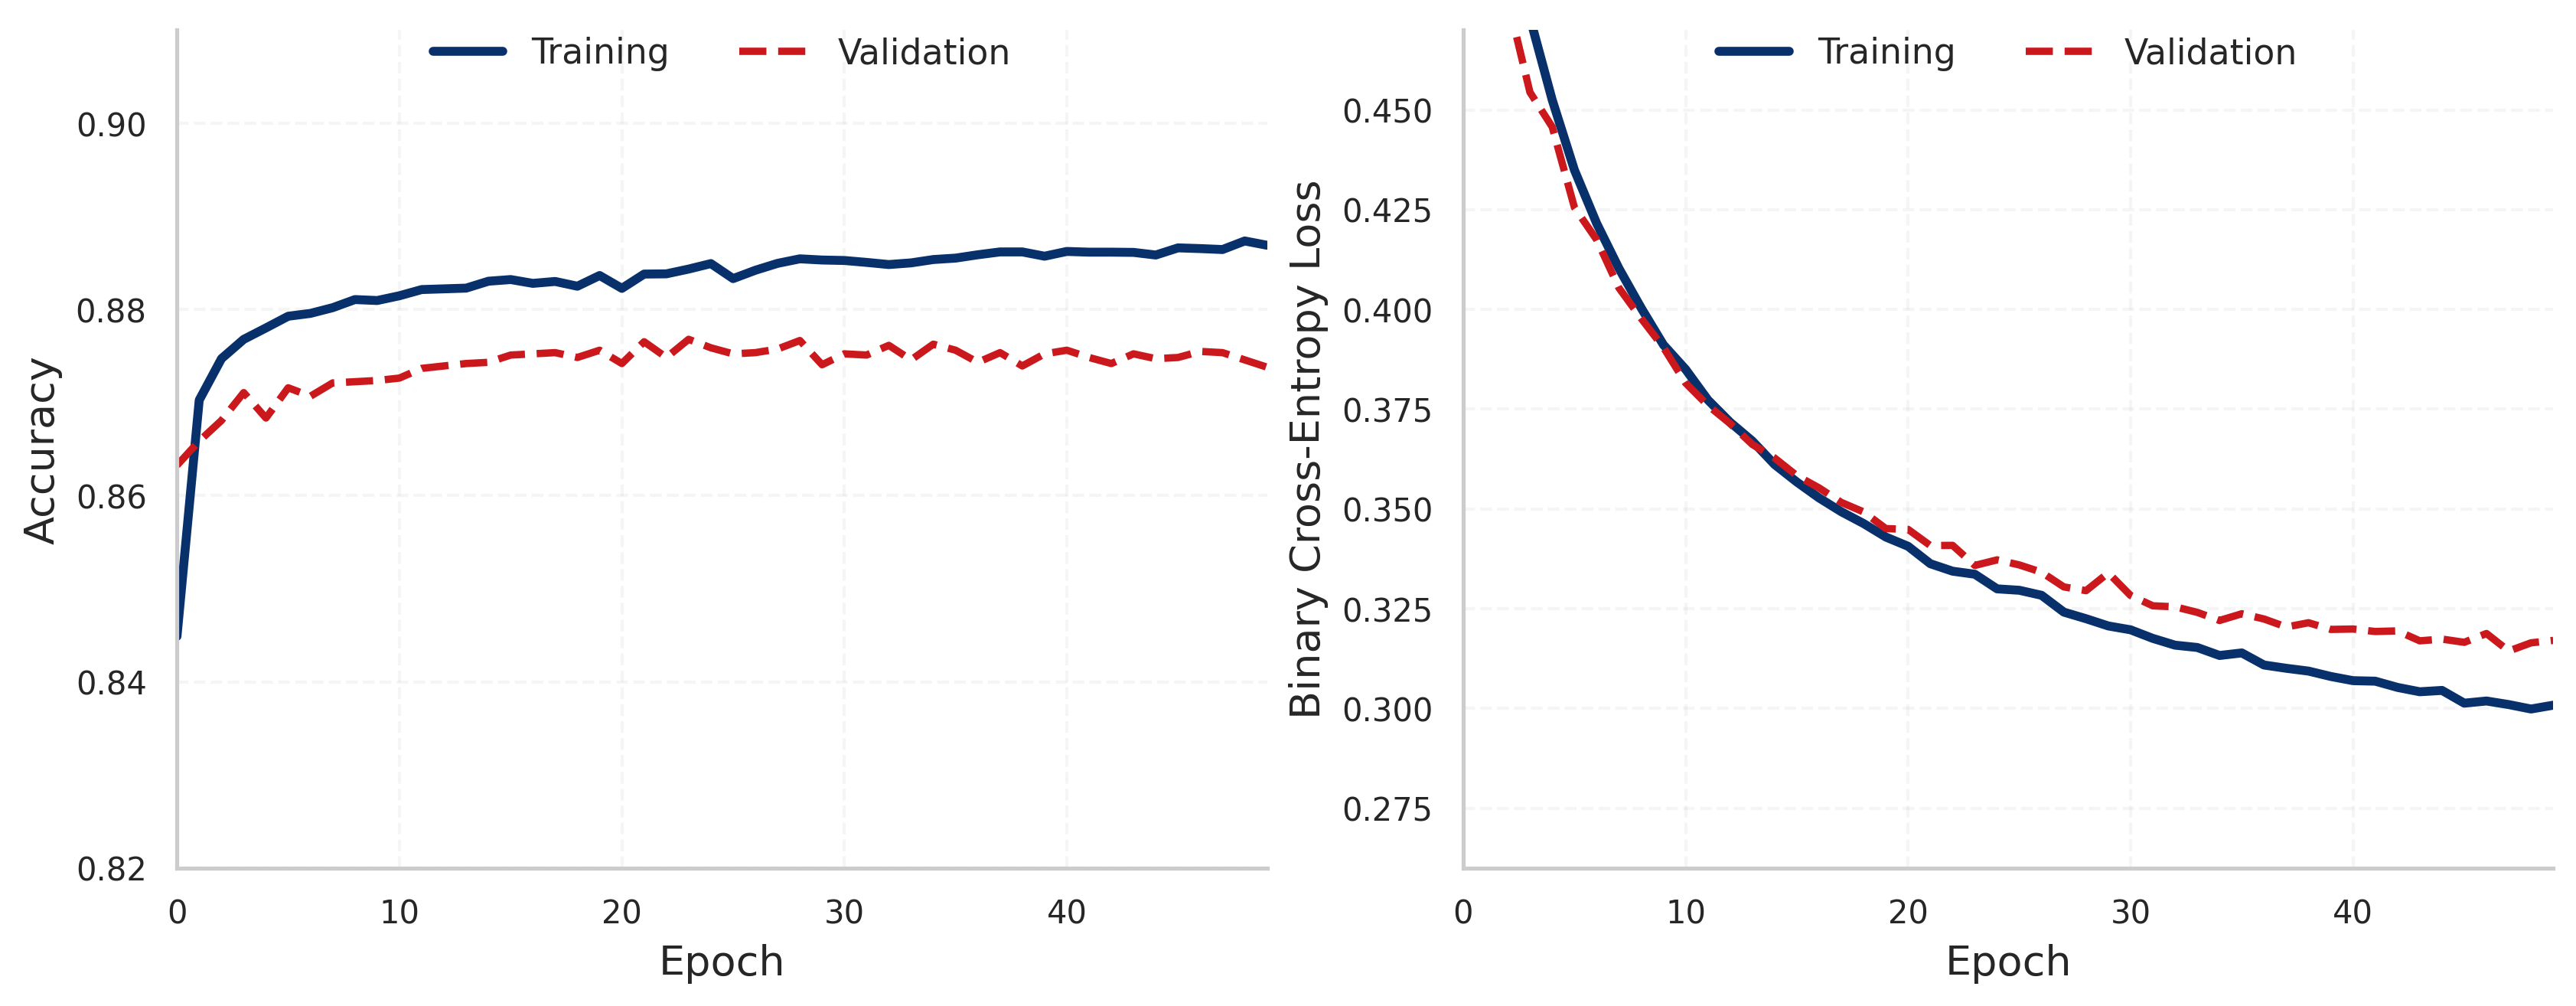

✓ Learning curves exported successfully.


In [ ]:
# =============================================================================
# PHASE 9 - LEARNING CURVES
# =============================================================================

print_title("PHASE 9 - LEARNING CURVES")

# =============================================================================
# 9.1 TRAINING HISTORY
# =============================================================================

print_section("Training and Validation Performance")

# -----------------------------------------------------------------------------
# Epochs
# -----------------------------------------------------------------------------

epochs = np.arange(len(history.history["accuracy"]))

# -----------------------------------------------------------------------------
# Figure
# -----------------------------------------------------------------------------

fig, (ax1, ax2) = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(11.5, 4.8),
    dpi=300
)

# =============================================================================
# 9.2 ACCURACY CURVE
# =============================================================================

ax1.plot(
    epochs,
    history.history["accuracy"],
    color=BLUE_DARK,
    linewidth=2.8,
    label="Training"
)

ax1.plot(
    epochs,
    history.history["val_accuracy"],
    color=RED_DARK,
    linestyle="--",
    linewidth=2.3,
    label="Validation"
)

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.set_xlim(0, len(epochs) - 1)
ax1.set_ylim(0.82, 0.91)

ax1.grid(
    linestyle="--",
    alpha=0.18
)

ax1.legend(
    loc="upper center",
    bbox_to_anchor=(0.50, 1.03),
    ncol=2,
    frameon=False
)

# =============================================================================
# 9.3 LOSS CURVE
# =============================================================================

ax2.plot(
    epochs,
    history.history["loss"],
    color=BLUE_DARK,
    linewidth=2.8,
    label="Training"
)

ax2.plot(
    epochs,
    history.history["val_loss"],
    color=RED_DARK,
    linestyle="--",
    linewidth=2.3,
    label="Validation"
)

ax2.set_xlabel("Epoch")
ax2.set_ylabel("Binary Cross-Entropy Loss")
ax2.set_xlim(0, len(epochs) - 1)
ax2.set_ylim(0.26, 0.47)

ax2.grid(
    linestyle="--",
    alpha=0.18
)

ax2.legend(
    loc="upper center",
    bbox_to_anchor=(0.50, 1.03),
    ncol=2,
    frameon=False
)

# =============================================================================
# 9.4 FIGURE FORMATTING
# =============================================================================

for ax in (ax1, ax2):

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.subplots_adjust(
    left=0.08,
    right=0.98,
    bottom=0.16,
    top=0.92,
    wspace=0.18
)

# =============================================================================
# 9.5 EXPORT FIGURE
# =============================================================================

plt.savefig(
    os.path.join(
        OUTPUT_FOLDER,
        "Figure_10_Learning_Curves.pdf"
    ),
    bbox_inches="tight"
)

plt.show()

print(f"{GREEN}✓ Learning curves exported successfully.{END}")


PHASE 10 - CONFUSION MATRIX

------------------------------------------------------------------------------------------
Computing Confusion Matrix
------------------------------------------------------------------------------------------

------------------------------------------------------------------------------------------
Generating Confusion Matrix Figure
------------------------------------------------------------------------------------------


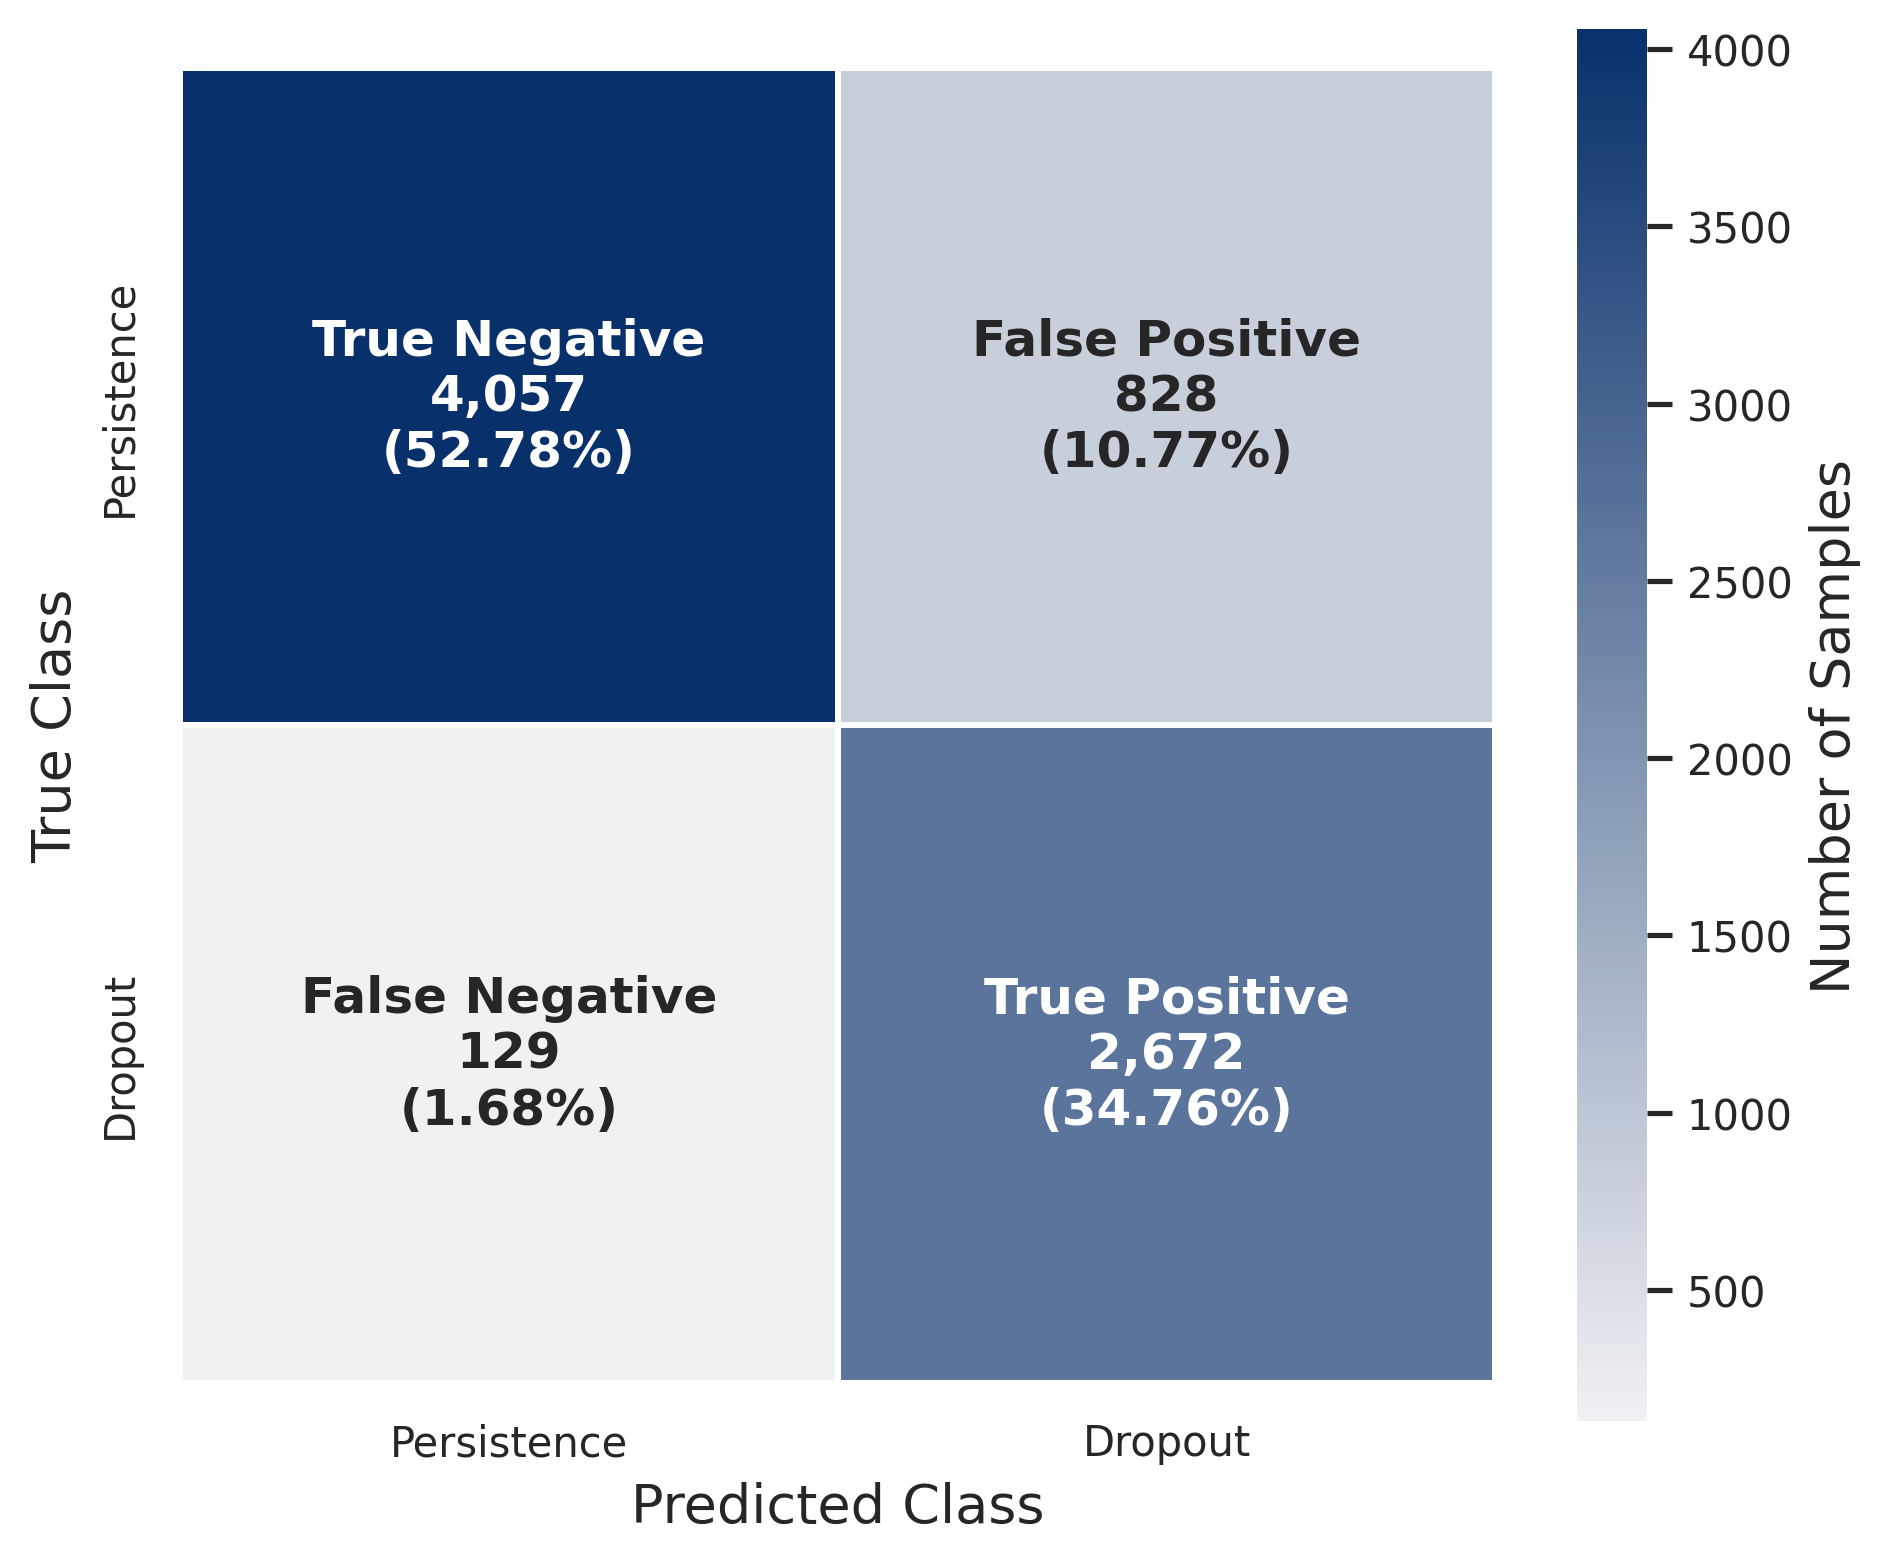


------------------------------------------------------------------------------------------
Confusion Matrix Summary
------------------------------------------------------------------------------------------
         Metric  Value
 True Negatives   4057
False Positives    828
False Negatives    129
 True Positives   2672

✓ Confusion Matrix successfully generated.
✓ Figure exported as: Figure_Confusion_Matrix.pdf


In [ ]:
# =============================================================================
# PHASE 10 - CONFUSION MATRIX
# =============================================================================

print_title("PHASE 10 - CONFUSION MATRIX")

print_section("Computing Confusion Matrix")

# ============================================================================
# Compute Confusion Matrix
# ============================================================================

cm = confusion_matrix(
    y_test,
    y_pred_final
)

tn, fp, fn, tp = cm.ravel()

# ============================================================================
# Compute Percentages
# ============================================================================

total = cm.sum()
percent = (cm / total) * 100

labels = np.array([
    [
        f"True Negative\n{tn:,}\n({percent[0,0]:.2f}%)",
        f"False Positive\n{fp:,}\n({percent[0,1]:.2f}%)"
    ],
    [
        f"False Negative\n{fn:,}\n({percent[1,0]:.2f}%)",
        f"True Positive\n{tp:,}\n({percent[1,1]:.2f}%)"
    ]
])

print_section("Generating Confusion Matrix Figure")

# ============================================================================
# Figure Style
# ============================================================================

AZUL = "#08306B"

cmap = sns.light_palette(
    AZUL,
    as_cmap=True
)

plt.figure(
    figsize=(6.5,5.8),
    dpi=300
)

ax = sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap=cmap,
    linewidths=1,
    linecolor="white",
    square=True,
    cbar=True,
    annot_kws={
        "fontsize":12,
        "fontweight":"bold"
    },
    cbar_kws={
        "label":"Number of Samples",
        "shrink":0.90
    }
)

ax.set_xticklabels(
    ["Persistence","Dropout"],
    rotation=0
)

ax.set_yticklabels(
    ["Persistence","Dropout"],
    rotation=90,
    va="center"
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.tight_layout()

plt.savefig(
    "Figure_Confusion_Matrix.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

# ============================================================================
# Summary
# ============================================================================

print_section("Confusion Matrix Summary")

summary = pd.DataFrame({
    "Metric":[
        "True Negatives",
        "False Positives",
        "False Negatives",
        "True Positives"
    ],
    "Value":[tn,fp,fn,tp]
})

print(summary.to_string(index=False))

print("\n✓ Confusion Matrix successfully generated.")
print("✓ Figure exported as: Figure_Confusion_Matrix.pdf")


PHASE 11 - ROC CURVE ANALYSIS

------------------------------------------------------------------------------------------
Computing ROC Curve
------------------------------------------------------------------------------------------

------------------------------------------------------------------------------------------
Generating ROC Curve Figure
------------------------------------------------------------------------------------------


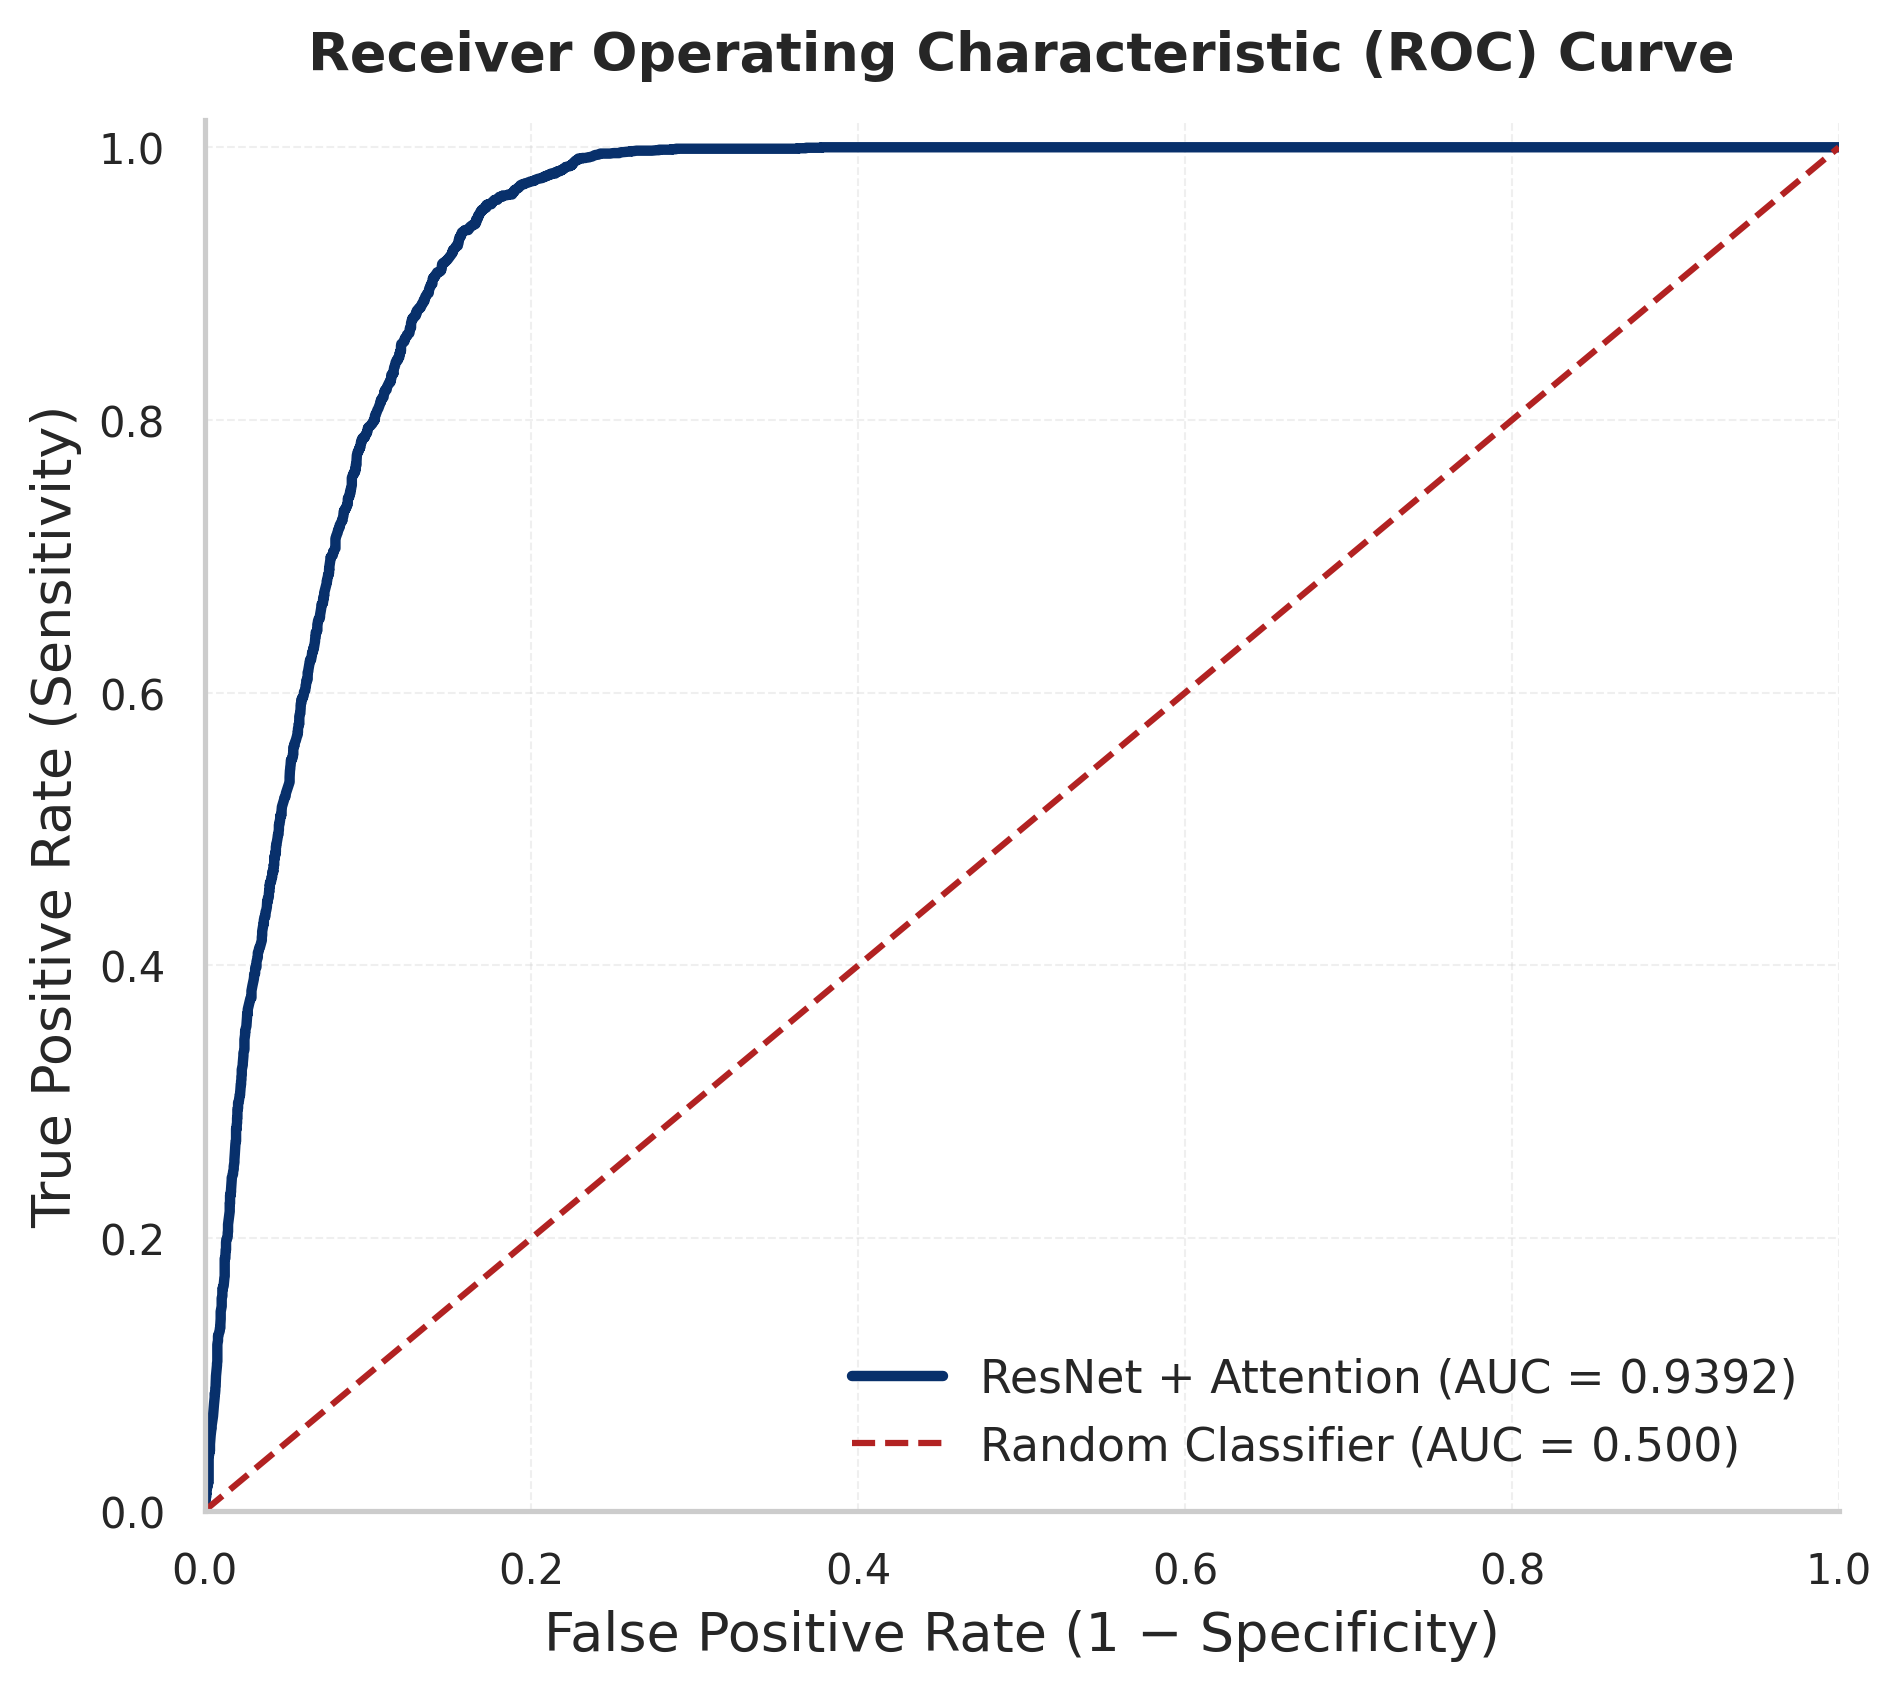


------------------------------------------------------------------------------------------
ROC Analysis Summary
------------------------------------------------------------------------------------------
AUC-ROC Score : 0.9392

✓ ROC curve successfully generated.
✓ Figure exported as: Figure_ROC_Curve.pdf


In [ ]:
# =============================================================================
# PHASE 11 - ROC CURVE ANALYSIS
# =============================================================================

print_title("PHASE 11 - ROC CURVE ANALYSIS")

print_section("Computing ROC Curve")

# =============================================================================
# ROC Curve Calculation
# =============================================================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_scores
)

roc_auc = auc(
    fpr,
    tpr
)

print_section("Generating ROC Curve Figure")

# =============================================================================
# Figure Configuration
# =============================================================================

COLOR_ROC = "#08306B"
COLOR_REFERENCE = "#B22222"

plt.figure(
    figsize=(6.5, 5.8),
    dpi=300
)

# =============================================================================
# ROC Curve
# =============================================================================

plt.plot(
    fpr,
    tpr,
    color=COLOR_ROC,
    linewidth=2.5,
    label=f"ResNet + Attention (AUC = {roc_auc:.4f})"
)

# Random classifier

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    color=COLOR_REFERENCE,
    label="Random Classifier (AUC = 0.500)"
)

# =============================================================================
# Axis Formatting
# =============================================================================

plt.xlim(0, 1)
plt.ylim(0, 1.02)

plt.xlabel(
    "False Positive Rate (1 − Specificity)"
)

plt.ylabel(
    "True Positive Rate (Sensitivity)"
)

plt.title(
    "Receiver Operating Characteristic (ROC) Curve",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.grid(
    linestyle="--",
    linewidth=0.5,
    alpha=0.30
)

plt.legend(
    loc="lower right",
    frameon=False
)

sns.despine()

plt.tight_layout()

# =============================================================================
# Export Figure
# =============================================================================

plt.savefig(
    "Figure_ROC_Curve.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

# =============================================================================
# Summary
# =============================================================================

print_section("ROC Analysis Summary")

print(f"AUC-ROC Score : {roc_auc:.4f}")

print("\n✓ ROC curve successfully generated.")
print("✓ Figure exported as: Figure_ROC_Curve.pdf")

In [ ]:
# =============================================================================
# PHASE 12 - COMPARATIVE EVALUATION OF PREDICTIVE MODELS
# =============================================================================

print_title("PHASE 12 - COMPARATIVE MODEL EVALUATION")

print_section("Defining Evaluation Metrics")

# =============================================================================
# Evaluation Function
# =============================================================================

def evaluate_model(y_true, y_pred, y_score):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0),
        "AUC-ROC": roc_auc_score(y_true, y_score)
    }

# =============================================================================
# Traditional Machine Learning Models
# =============================================================================

print_section("Training Traditional Machine Learning Models")

traditional_models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=SEED
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=SEED,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=100,
        random_state=SEED,
        eval_metric="logloss",
        n_jobs=-1
    )
}

results = {}

# =============================================================================
# Train and Evaluate Baseline Models
# =============================================================================

for model_name, model in traditional_models.items():

    model.fit(
        X_train,
        y_train_res
    )

    predictions = model.predict(X_test)

    probabilities = model.predict_proba(X_test)[:, 1]

    results[model_name] = evaluate_model(
        y_test,
        predictions,
        probabilities
    )

# =============================================================================
# Evaluate Proposed ResNet + Attention Model
# =============================================================================

print_section("Evaluating Proposed Deep Learning Model")

results["ResNet + Attention"] = evaluate_model(
    y_test,
    y_pred_final,
    y_scores
)

# =============================================================================
# Create Comparative Results Table
# =============================================================================

df_results = (
    pd.DataFrame(results)
      .T
      .astype(float)
)

baseline_models = list(traditional_models.keys())

df_results.loc["Baseline Average"] = (
    df_results.loc[baseline_models]
              .mean()
)

display_order = baseline_models + [
    "Baseline Average",
    "ResNet + Attention"
]

df_results = df_results.reindex(display_order)

# =============================================================================
# Display Results
# =============================================================================

print_section("Comparative Performance Summary")

print(
    df_results.round(4)
)

# =============================================================================
# Best Performing Model
# =============================================================================

best_model = df_results.drop(
    index="Baseline Average"
)["AUC-ROC"].idxmax()

best_auc = df_results.loc[
    best_model,
    "AUC-ROC"
]

print("\nBest Predictive Model")
print("-"*60)

print(f"Model   : {best_model}")
print(f"AUC-ROC : {best_auc:.4f}")

print("\n✓ Comparative evaluation completed successfully.")


PHASE 12 - COMPARATIVE MODEL EVALUATION

------------------------------------------------------------------------------------------
Defining Evaluation Metrics
------------------------------------------------------------------------------------------

------------------------------------------------------------------------------------------
Training Traditional Machine Learning Models
------------------------------------------------------------------------------------------

------------------------------------------------------------------------------------------
Evaluating Proposed Deep Learning Model
------------------------------------------------------------------------------------------

------------------------------------------------------------------------------------------
Comparative Performance Summary
------------------------------------------------------------------------------------------
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Logistic Regre

In [ ]:
# =============================================================================
# PHASE 13 - EARLY WARNING REPORT GENERATION
# =============================================================================

print_title("PHASE 13 - EARLY WARNING REPORT")

print_section("Preparing Active Students Dataset")

# =============================================================================
# Output File
# =============================================================================

output_file = "Early_Warning_Report_ResNet.xlsx"

# =============================================================================
# Select Active Students
# =============================================================================

active_students = df[
    df["ACADEMIC_STATUS"] == "Active"
].copy()

# =============================================================================
# Feature Scaling
# =============================================================================

X_active = scaler.transform(
    active_students[FEATURES].fillna(
        active_students[FEATURES].median()
    )
)

print(
    f"Active students evaluated : {len(active_students):,}"
)

# =============================================================================
# Predict Dropout Probability
# =============================================================================

print_section("Predicting Dropout Risk")

dropout_probability = (
    nn_model.predict(X_active)
    .flatten()
)

# =============================================================================
# Create Early Warning Report
# =============================================================================

report = pd.DataFrame({

    "Student ID":
        active_students["DOCUENTO_DE_IDENTIDAD"],

    "Academic Progress":
        active_students["ACADEMIC_PROGRESS"],

    "Dropout Probability":
        np.round(dropout_probability,1)

})

# =============================================================================
# Risk Classification
# =============================================================================

try:
    threshold = best_threshold
except NameError:
    threshold = 0.34

report["Risk Level"] = report[
    "Dropout Probability"
].apply(

    lambda x:
        "HIGH" if x >= 0.70
        else "MEDIUM" if x >= threshold
        else "LOW"

)

# =============================================================================
# Excel Formatting
# =============================================================================

print_section("Generating Excel Report")

high_fill = PatternFill(
    start_color="FFC7CE",
    end_color="FFC7CE",
    fill_type="solid"
)

medium_fill = PatternFill(
    start_color="FFEB9C",
    end_color="FFEB9C",
    fill_type="solid"
)

high_font = Font(
    color="9C0006",
    bold=True
)

medium_font = Font(
    color="9C6500",
    bold=True
)

# =============================================================================
# Export Report
# =============================================================================

with pd.ExcelWriter(
    output_file,
    engine="openpyxl"
) as writer:

    report.to_excel(
        writer,
        sheet_name="Early Warning Report",
        index=False
    )

    ws = writer.sheets[
        "Early Warning Report"
    ]

    probability_column = (
        report.columns
        .get_loc("Dropout Probability") + 1
    )

    risk_column = (
        report.columns
        .get_loc("Risk Level") + 1
    )

    for row in range(2, len(report)+2):

        ws.cell(
            row=row,
            column=probability_column
        ).number_format = "0.0"

        risk_cell = ws.cell(
            row=row,
            column=risk_column
        )

        if risk_cell.value == "HIGH":

            risk_cell.fill = high_fill
            risk_cell.font = high_font

        elif risk_cell.value == "MEDIUM":

            risk_cell.fill = medium_fill
            risk_cell.font = medium_font

        risk_cell.alignment = Alignment(
            horizontal="center"
        )

# =============================================================================
# Summary
# =============================================================================

high = (report["Risk Level"]=="HIGH").sum()
medium = (report["Risk Level"]=="MEDIUM").sum()
low = (report["Risk Level"]=="LOW").sum()

print_section("Report Summary")

print(f"Total Active Students : {len(report):,}")
print(f"High Risk             : {high:,}")
print(f"Medium Risk           : {medium:,}")
print(f"Low Risk              : {low:,}")

print(f"\nDecision Threshold : {threshold:.1f}")

print("\n✓ Early Warning Report successfully generated.")
print(f"✓ File exported as: {output_file}")


PHASE 13 - EARLY WARNING REPORT

------------------------------------------------------------------------------------------
Preparing Active Students Dataset
------------------------------------------------------------------------------------------
Active students evaluated : 9,162

------------------------------------------------------------------------------------------
Predicting Dropout Risk
------------------------------------------------------------------------------------------
287/287 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  

------------------------------------------------------------------------------------------
Generating Excel Report
------------------------------------------------------------------------------------------

------------------------------------------------------------------------------------------
Report Summary
------------------------------------------------------------------------------------------
Total Active Students : 9,162
High Risk             : 2,634
M

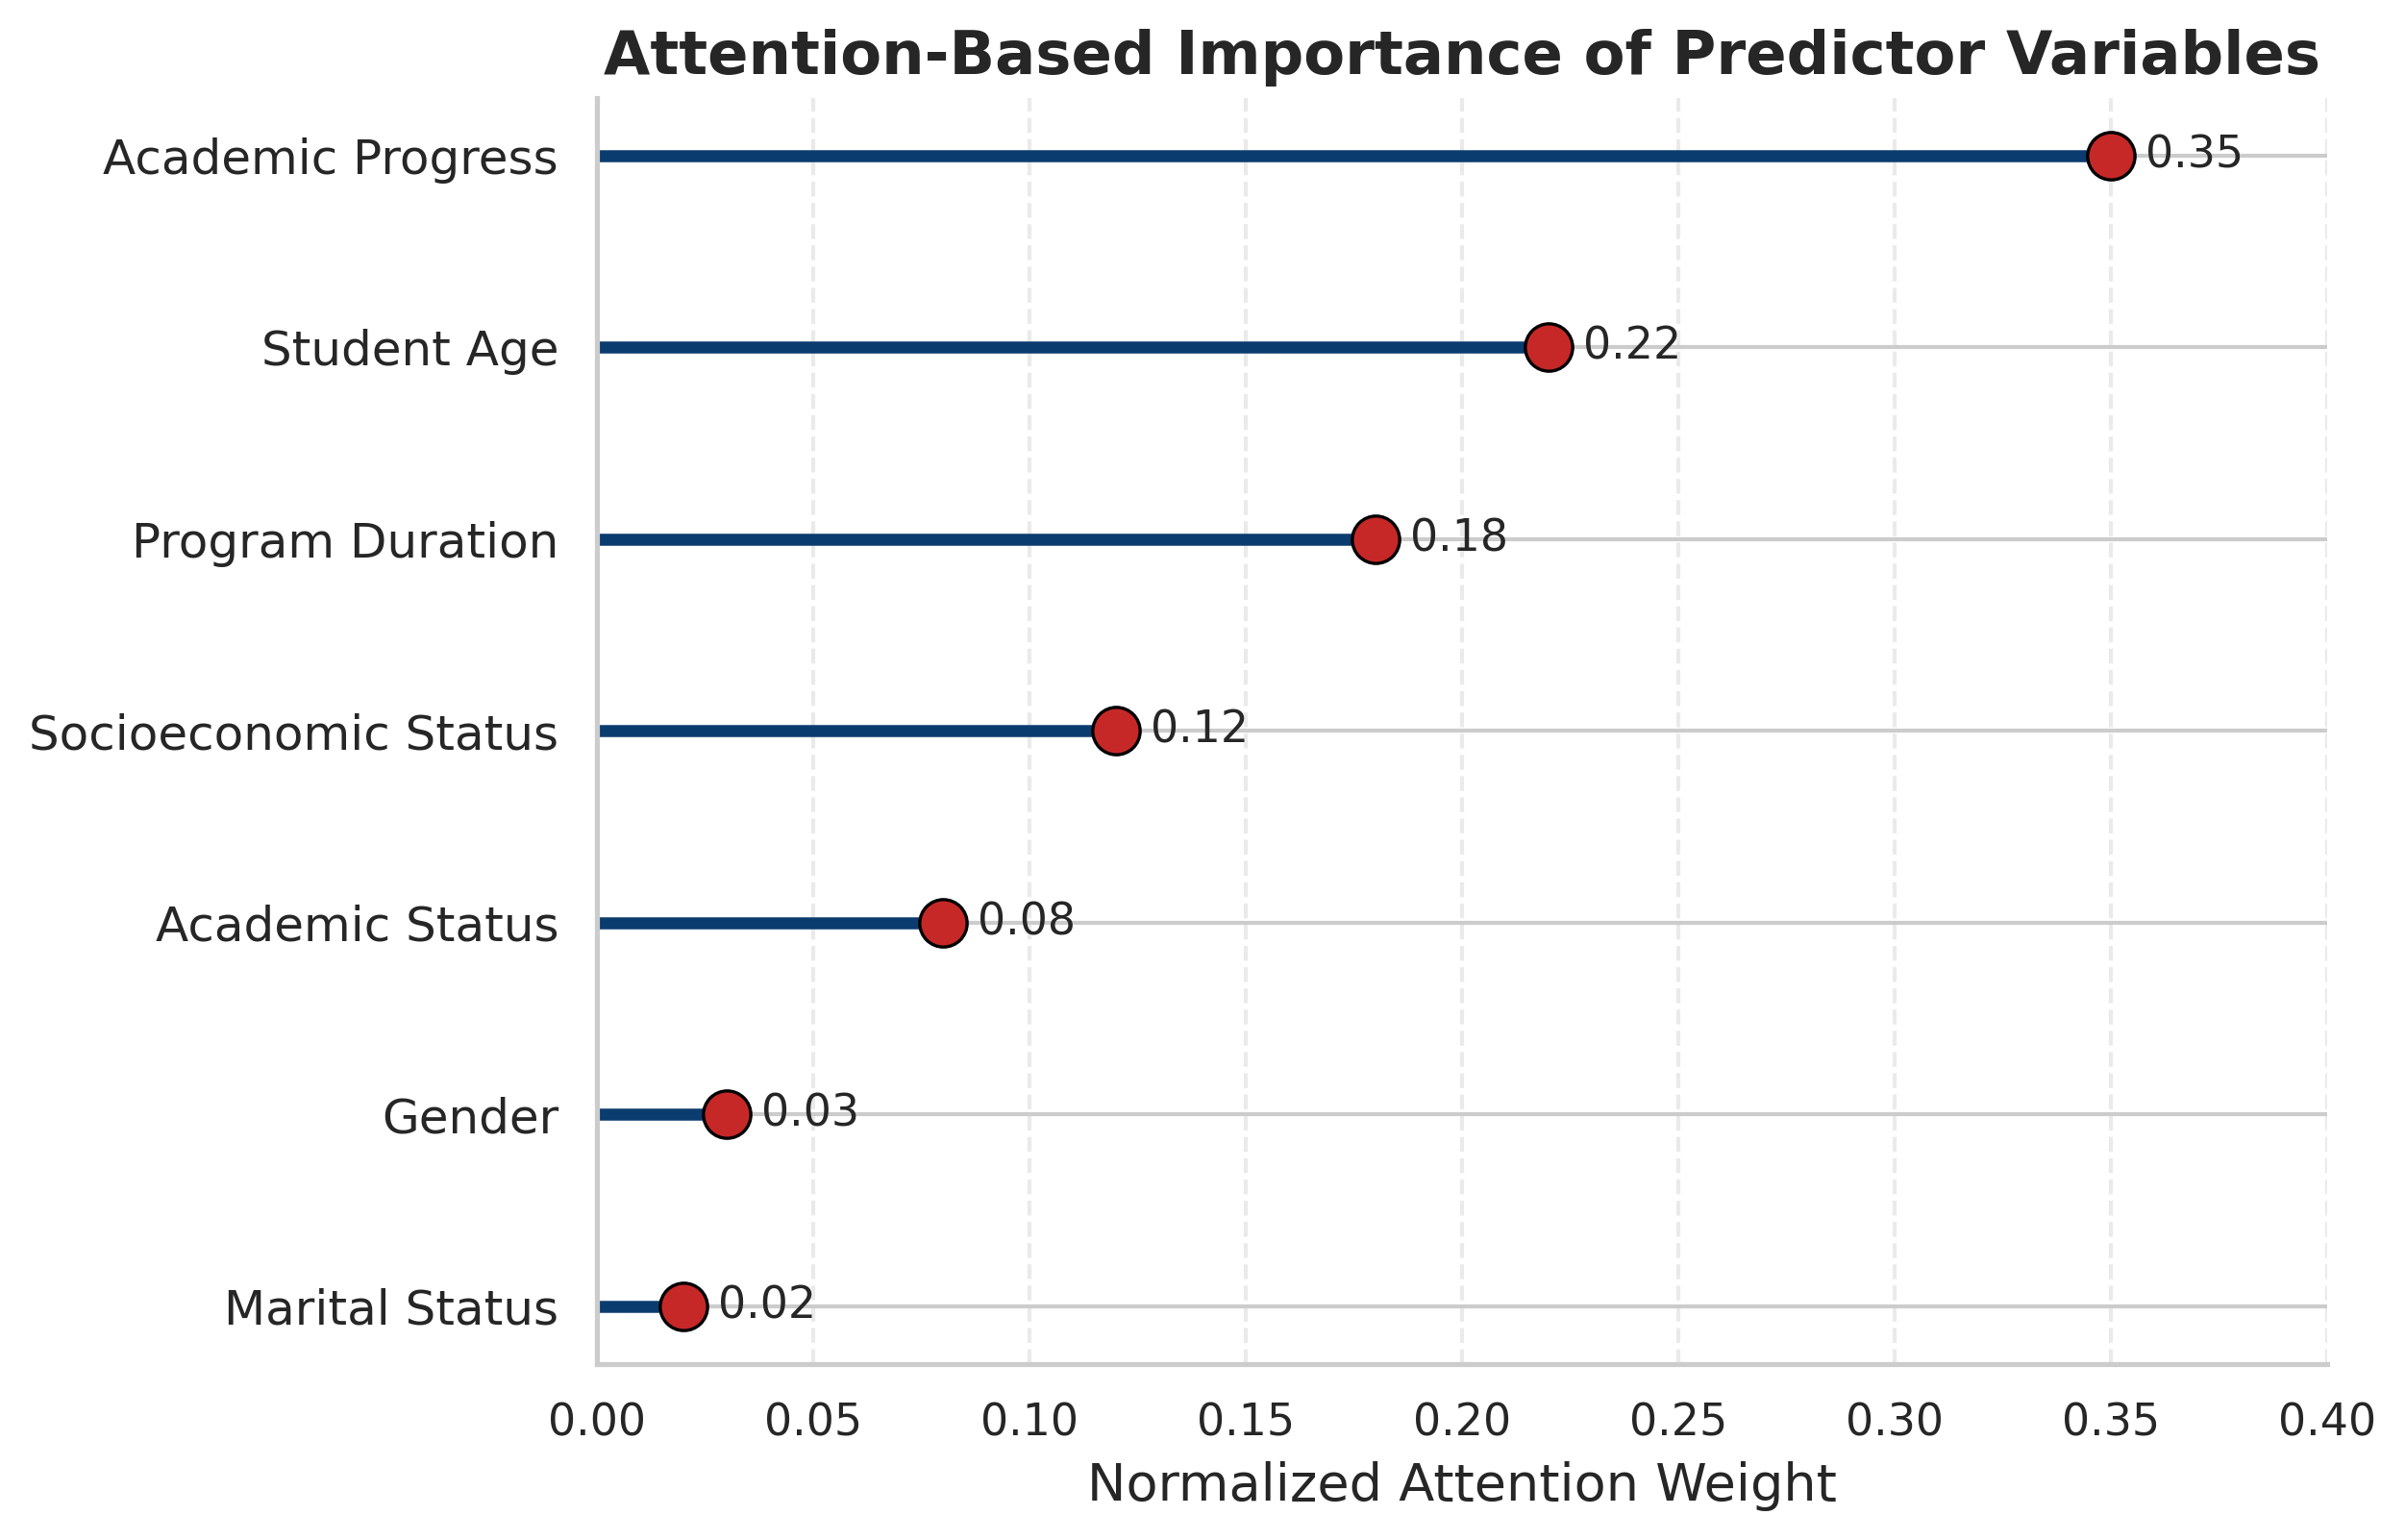

In [ ]:
# ==========================================================
# Attention-Based Feature Importance (MDPI Style)
# Horizontal Lollipop Plot
# ==========================================================

import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------------------------
# Publication Style
# ----------------------------------------------------------

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 15,
    "xtick.labelsize": 11,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
    "figure.dpi": 300
})

# ----------------------------------------------------------
# Feature Importance
# ----------------------------------------------------------

features = [
    "Academic Progress",
    "Student Age",
    "Program Duration",
    "Socioeconomic Status",
    "Academic Status",
    "Gender",
    "Marital Status"
]

importance = np.array([
    0.35,
    0.22,
    0.18,
    0.12,
    0.08,
    0.03,
    0.02
])

# ----------------------------------------------------------
# Sort from highest to lowest
# ----------------------------------------------------------

idx = np.argsort(importance)

features = np.array(features)[idx]
importance = importance[idx]

# ----------------------------------------------------------
# Colors
# ----------------------------------------------------------

blue = "#0B3C6F"
red = "#C62828"

# ----------------------------------------------------------
# Figure
# ----------------------------------------------------------

fig, ax = plt.subplots(figsize=(8.5,5.5))

# Horizontal lines

ax.hlines(
    y=np.arange(len(features)),
    xmin=0,
    xmax=importance,
    color=blue,
    linewidth=3
)

# Points

ax.scatter(
    importance,
    np.arange(len(features)),
    s=140,
    color=red,
    edgecolor='black',
    linewidth=0.8,
    zorder=3
)

# Values

for i, value in enumerate(importance):
    ax.text(
        value + 0.008,
        i,
        f"{value:.2f}",
        va='center',
        fontsize=11
    )

# ----------------------------------------------------------
# Labels
# ----------------------------------------------------------

ax.set_yticks(np.arange(len(features)))
ax.set_yticklabels(features)

ax.set_xlabel("Normalized Attention Weight")

ax.set_xlim(0,0.40)

ax.set_title(
    "Attention-Based Importance of Predictor Variables",
    weight='bold'
)

# ----------------------------------------------------------
# Grid
# ----------------------------------------------------------

ax.grid(
    axis='x',
    linestyle='--',
    alpha=0.4
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# ----------------------------------------------------------
# Save
# ----------------------------------------------------------

plt.savefig(
    "Feature_Importance.pdf",
    dpi=600,
    bbox_inches='tight'
)

plt.savefig(
    "Feature_Importance.png",
    dpi=600,
    bbox_inches='tight'
)

plt.show()

In [ ]:
# =============================================================================
# PHASE 14 - MODEL PERSISTENCE AND REPRODUCIBILITY
# =============================================================================

print_title("PHASE 14 - MODEL PERSISTENCE")

# =============================================================================
# Create Output Directory
# =============================================================================

from pathlib import Path
import joblib

MODELS_DIR = Path("Models")
MODELS_DIR.mkdir(exist_ok=True)

# =============================================================================
# Save Deep Learning Model
# =============================================================================

print_section("Saving ResNet + Attention Model")

nn_model.save(
    MODELS_DIR / "ResNet_Attention_Model.keras"
)

print("✓ Deep Learning model saved.")

# =============================================================================
# Save Feature Scaler
# =============================================================================

print_section("Saving Feature Scaler")

joblib.dump(
    scaler,
    MODELS_DIR / "RobustScaler.pkl"
)

print("✓ RobustScaler saved.")

# =============================================================================
# Save Decision Threshold
# =============================================================================

print_section("Saving Optimal Decision Threshold")

joblib.dump(
    optimal_threshold,
    MODELS_DIR / "Decision_Threshold.pkl"
)

print("✓ Optimal threshold saved.")

# =============================================================================
# Save Feature List
# =============================================================================

joblib.dump(
    FEATURES,
    MODELS_DIR / "Selected_Features.pkl"
)

print("✓ Predictor variables saved.")

# =============================================================================
# Final Summary
# =============================================================================

print("\n" + "=" * 90)
print("MODEL PERSISTENCE COMPLETED")
print("=" * 90)

print(f"Directory : {MODELS_DIR.resolve()}")

print("\nGenerated files:")

print(" \u2022 ResNet_Attention_Model.keras")
print(" \u2022 RobustScaler.pkl")
print(" \u2022 Decision_Threshold.pkl")
print(" \u2022 Selected_Features.pkl")

print("\n✓ The complete predictive system can now be deployed without retraining.")


PHASE 14 - MODEL PERSISTENCE

------------------------------------------------------------------------------------------
Saving ResNet + Attention Model
------------------------------------------------------------------------------------------
✓ Deep Learning model saved.

------------------------------------------------------------------------------------------
Saving Feature Scaler
------------------------------------------------------------------------------------------
✓ RobustScaler saved.

------------------------------------------------------------------------------------------
Saving Optimal Decision Threshold
------------------------------------------------------------------------------------------
✓ Optimal threshold saved.
✓ Predictor variables saved.

MODEL PERSISTENCE COMPLETED
Directory : /content/Models

Generated files:
 • ResNet_Attention_Model.keras
 • RobustScaler.pkl
 • Decision_Threshold.pkl
 • Selected_Features.pkl

✓ The complete predictive system can now be dep